<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%A0%D0%B5%D0%BA%D1%83%D1%80%D1%80%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B5_%D0%B8_%D0%BE%D0%B4%D0%BD%D0%BE%D0%BC%D0%B5%D1%80%D0%BD%D1%8B%D0%B5_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_(%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_1)_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Содержание темы**

1. [Теория](https://colab.research.google.com/drive/1-T3yr1Qc7KW0KOYwRdYh5x6woNyMXelj?usp=sharing)

2. Практический ноутбук



Теперь вы можете перейти к практической части урока по рекуррентным и сверточным
сетям. Вы решите уже знакомую задачу по классификации текстов писателей. Проведете полноценное исследование и попробуете разные архитектуры, познакомитесь с тем, как происходит работа нейронщика при подборе параметров.

##Обработка текстов рекуррентными и сверточными сетями: классификация художественных текстов

###Импорт библиотек

Подключите библиотеки и инструменты. Большинство уже известны, из нового – слои
**SimpleRNN**, **GRU**, **LSTM**, **Bidirectional**, **MaxPooling1D**, **GlobalMaxPooling1D**.

In [1]:
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Рисование схемы модели
from tensorflow.keras.utils import plot_model

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Вывод объектов в ячейке colab
from IPython.display import display

%matplotlib inline

Рассмотрите подробнее два последних. Логика работы одинаковая, отличие только в
размере окна проходки. Если возьмете тензор (1,2,3,4,7,2), то при проходке окном в 2 единицы **MaxPooling1D** выдаст тензор (2,4,7), так как берет максимум в окне. **GlobalMaxPooling1D** выдаст тензор (7), так как его окно всегда равняется максимально возможному размеру тензора.

###Загрузка датасета и подготовка данных

Загрузите архив с текстами:

In [2]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

Разархивируйте его и посмотрите на содержимое:

In [3]:
# Распаковка архива в папку writers
!unzip -qo writers.zip -d writers/

# Просмотр содержимого папки
!ls writers

'(Булгаков) Обучающая_5 вместе.txt'	    '(О. Генри) Обучающая_50 вместе.txt'
'(Булгаков) Тестовая_2 вместе.txt'	    '(О. Генри) Тестовая_20 вместе.txt'
'(Клиффорд_Саймак) Обучающая_5 вместе.txt'  '(Рэй Брэдберри) Обучающая_22 вместе.txt'
'(Клиффорд_Саймак) Тестовая_2 вместе.txt'   '(Рэй Брэдберри) Тестовая_8 вместе.txt'
'(Макс Фрай) Обучающая_5 вместе.txt'	    '(Стругацкие) Обучающая_5 вместе.txt'
'(Макс Фрай) Тестовая_2 вместе.txt'	    '(Стругацкие) Тестовая_2 вместе.txt'


Создайте константы, которые упростят дальнейшую работу:

In [4]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # Папка с текстовыми файлами
SIG_TRAIN = 'обучающая'                   # Признак обучающей выборки в имени файла
SIG_TEST  = 'тестовая'                    # Признак тестовой выборки в имени файла

Загрузите все тексты. Для начала получите список всех текстов и отсортируйте – разбейте названия текстов на отдельные слова. Затем, на основе разбивки, распределите тексты по классам и выборкам. Выведите результат обработки на экран и запишите количество классов в отдельную переменную.

In [5]:
# Загрузка датасета. Добавляются имена классов и соответствующие тексты.
# Все тексты преобразуются в строку и объединяются для каждого класса и выборки
CLASS_LIST = []
text_train = []
text_test = []

# Получение списка файлов в папке
file_list = os.listdir(FILE_DIR)
# Сортировка списка файлов для фиксации порядка меток на случай сохраненния данных
file_list.sort()

for file_name in file_list:
    # Выделение имени класса и типа выборки из имени файла
    m = re.match('\((.+)\) (\S+)_', file_name)
    # Если выделение получилось, то файл обрабатывается
    if m:
        class_name = m[1]
        subset_name = m[2].lower()
        # Проверка типа выборки в имени файла
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name

        # Если тип выборки обучающая либо тестовая - файл обрабатывается
        if is_train or is_test:
            # Добавление нового класса, если его еще нет в списке
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)
                # Инициализация соответствующих классу строк текста
                text_train.append('')
                text_test.append('')

            # Поиск индекса класса для добавления содержимого файла в выборку
            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')
            with open(f'{FILE_DIR}/{file_name}', 'r') as f:
                # Загрузка содержимого файла в строку
                text = f.read()
            # Определение выборки, куда будет добавлено содержимое
            subset = text_train if is_train else text_test
            # Добавление текста к соответствующей выборке класса. Концы строк заменяются на пробел
            subset[cls] += ' ' + text.replace('\n', ' ')

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

Добавление класса "Булгаков"
Добавление файла "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков", обучающая выборка.
Добавление файла "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков", тестовая выборка.
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Обучающая_5 вместе.txt" в класс "Клиффорд_Саймак", обучающая выборка.
Добавление файла "(Клиффорд_Саймак) Тестовая_2 вместе.txt" в класс "Клиффорд_Саймак", тестовая выборка.
Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Обучающая_5 вместе.txt" в класс "Макс Фрай", обучающая выборка.
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка.
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Обучающая_50 вместе.txt" в класс "О. Генри", обучающая выборка.
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберр

Посмотрите информацию по классам и содержащиеся в нем тексты ниже:

In [6]:
# Прочитанные классы текстов
print(CLASS_LIST)

# Количество текстов в обучающей выборке
print(len(text_train))

# Количество символов в первом источнике в trainText
print(len(text_train[3]))

['Булгаков', 'Клиффорд_Саймак', 'Макс Фрай', 'О. Генри', 'Рэй Брэдберри', 'Стругацкие']
6
1049518


In [7]:
# Проверка загрузки: вывод начальных отрывков из каждого класса
for cls in range(CLASS_COUNT):
    print(f'Класс: {CLASS_LIST[cls]}')
    print(f'  train: {text_train[cls][:200]}')
    print(f'  test : {text_test[cls][:200]}')
    print()

Класс: Булгаков
  train:  ﻿Белая гвардия   Посвящается[1]  Любови Евгеньевне Белозерской[2]  Пошел мелкий снег и вдруг повалил хло-  пьями. Ветер завыл; сделалась метель.  В одно мгновение темное небо смешалось с  снежным мор
  test :  ﻿Дон Кихот ДЕЙСТВУЮЩИЕ ЛИЦА Алонсо Кихано, он же Дон Кихот Ламанчский.  Антония – его племянница.  Ключница Дон Кихота.  Санчо Панса – оруженосец Дон Кихота.  Перо Перес – деревенский священник, лице

Класс: Клиффорд_Саймак
  train:  ﻿Всё живое...     Когда я выехал из нашего городишка и повернул на шоссе, позади оказался грузовик. Этакая тяжелая громадина с прицепом, и неслась она во весь дух. Шоссе здесь срезает угол городка, и
  test :  ﻿Зачарованное паломничество    1  Гоблин со стропил следил за прячущимся монахом, который шпионил за ученым. Гоблин ненавидел монаха и имел для этого все основания. Монах никого не ненавидел и не люб

Класс: Макс Фрай
  train:  ﻿Власть несбывшегося   – С тех пор как меня угораздило побывать в этой грешной Черхавле, мне

####Преобразование текстовых данных в числовые и векторные представления для обучения нейросети

Задайте параметры преобразования. Размер словаря для Bag-of-words установите в 20 000 самых популярных слов:

In [8]:
# Задание параметров преобразования
VOCAB_SIZE = 20000                        # Объем словаря для токенизатора
WIN_SIZE   = 1000                         # Длина отрезка текста (окна) в словах
WIN_HOP    = 100                          # Шаг окна разбиения текста на векторы

**Токенизация и преобразование в последовательности**

Создайте контекстный менеджер замера времени. Это отдельный класс, который можно
использовать при помощи `with timex()`. Логика его работы проста, но дает огромные возможности для экспериментов. Так как код исполняется построчно, в момент выполнения `with timex()` срабатывает код, прописанный в `def __enter__(self)`, то есть старт замера данных.

В момент окончания срабатывает функция `def __exit__(self, type, value, traceback)`, которая высчитывает разницу со стартовым временем и выводит результат. Синтаксис использования такой же, как и у цикла: вызов класса, код с отступами от края.

Синтаксис
with timex():
    <блок кода>
Работа.
1. До начала выполнения блока кода происходит выполнение  
метода __enter()__  .
Он фиксирует текущее время = t.

2. После выполнения блока кода происходит выполнения
метода __exit()__.
Он вычисляет время выполнения блока кода как разность текущего времени и t.

Почему в данном случае не использовать написанную функцию? Однозначного ответа
нет, каждый пишет свой код самостоятельно. Но этот самописный класс позволяет одной строчкой заменить две строки и улучшить читабельность кода. Возьмите на вооружение такой удобный инструмент.

В вот так, Dog - лучший друг всех котов (Cats), дает описание параметра **self**:

**dog‎**: у котов внутри есть мурчалка

**dog‎**: она реализована для всех
котов в классе «кот»

**‎dog‎**: в объекте «кот» надо как-то вызвать
метод «мурчало» у класса «кот»

**‎dog‎**: как ты это сделаешь? `dog‎:кот.мурчало()`

**‎dog‎**: если ты вызовешь `кот.мурчало()`, муркнут сразу все коты на свете

‎**dog**‎: а если ты вызовешь `self.мурчало()`, муркнет только тот кот, на которого указывает **self**.

In [9]:
# Контекстный менеджер для измерения времени операций
# Операция обертывается менеджером с помощью оператора with
class timex:
    def __enter__(self):
        # Фиксация времени старта процесса
        self.t = time.time()
        return self

    def __exit__(self, type, value, traceback):
        # Вывод времени работы
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

Используя самописный класс, токенизируйте текст и постройте частотный словарь по
обучающей выборке.

Параметры:
* `num_words=VOCAB_SIZE` – размер словаря;
* `filters='!&quot;#$%&amp;()*+,-–—./…:;&lt;=&gt;?@[\]^_{|}~«»\t\n\xa0\ufeff'` – знаки, которые будут фильтроваться;
* `lower=True` – перевод всех букв в нижний регистр;
* `split=''` – разделение слов друг от друга пробелами;
* `oov_token='неизвестное слово'` – неизвестные слова будут заменены на
«неизвестное слово»;
* **char_level** – если значение **True**, каждый символ будет рассмотрен как токен.

In [10]:
# Токенизация и построение частотного словаря по обучающим текстам
with timex():
    # Используется встроенный в Keras токенизатор для разбиения текста и построения частотного словаря
    tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff', lower=True, split=' ', oov_token='неизвестное_слово', char_level=False)

    # Использованы параметры:
    # num_words   - объем словаря
    # filters     - убираемые из текста ненужные символы
    # lower       - приведение слов к нижнему регистру
    # split       - разделитель слов
    # char_level  - указание разделять по словам, а не по единичным символам
    # oov_token   - токен для слов, которые не вошли в словарь

    # Построение частотного словаря по обучающим текстам
    tokenizer.fit_on_texts(text_train)

    # Построение словаря в виде пар слово - индекс
    items = list(tokenizer.word_index.items())

Время обработки: 2.40 с


Смотрите результаты:

In [12]:
# Вывод нескольких наиболее часто встречающихся слов
print(items[:120])

# Размер словаря может быть больше, чем num_words, но при преобразовании в последовательности
# и векторы bag of words будут учтены только первые num_words слов
print("Размер словаря", len(items))

[('неизвестное_слово', 1), ('и', 2), ('в', 3), ('не', 4), ('я', 5), ('что', 6), ('на', 7), ('с', 8), ('он', 9), ('а', 10), ('как', 11), ('то', 12), ('это', 13), ('но', 14), ('все', 15), ('у', 16), ('по', 17), ('его', 18), ('к', 19), ('так', 20), ('мне', 21), ('из', 22), ('за', 23), ('меня', 24), ('ты', 25), ('же', 26), ('бы', 27), ('сказал', 28), ('вы', 29), ('было', 30), ('от', 31), ('они', 32), ('мы', 33), ('только', 34), ('да', 35), ('еще', 36), ('она', 37), ('о', 38), ('вот', 39), ('когда', 40), ('если', 41), ('уже', 42), ('был', 43), ('нет', 44), ('ни', 45), ('их', 46), ('ну', 47), ('чтобы', 48), ('до', 49), ('для', 50), ('ему', 51), ('ничего', 52), ('может', 53), ('или', 54), ('даже', 55), ('там', 56), ('очень', 57), ('кто', 58), ('ее', 59), ('тут', 60), ('потом', 61), ('просто', 62), ('чем', 63), ('него', 64), ('быть', 65), ('теперь', 66), ('под', 67), ('где', 68), ('нас', 69), ('есть', 70), ('тебя', 71), ('ли', 72), ('время', 73), ('тебе', 74), ('вас', 75), ('со', 76), ('нибудь

Преобразуйте выборки обученным токенайзером в последовательность индексов:

In [15]:
# Преобразование обучающих и проверочных текстов текст в последовательности индексов согласно частотному словарю
with timex():
    seq_train = tokenizer.texts_to_sequences(text_train)
    seq_test = tokenizer.texts_to_sequences(text_test)

    print("Фрагмент обучающего текста:")
    print("В виде оригинального текста:              ", text_train[1][:101])
    print("Он же в виде последовательности индексов: ", seq_train[1][:20])

Фрагмент обучающего текста:
В виде оригинального текста:                ﻿Всё живое...     Когда я выехал из нашего городишка и повернул на шоссе, позади оказался грузовик. 
Он же в виде последовательности индексов:  [142, 2904, 40, 5, 11721, 22, 513, 1, 2, 1817, 7, 941, 956, 593, 2195, 12030, 4602, 1, 8, 1]
Время обработки: 3.13 с


Создайте функцию и выведите статистику по текстам:

In [16]:
# Функция вывода статистики по текстам
def print_text_stats(title, texts, sequences, class_labels=CLASS_LIST):
    # Суммарное количество символов и слов в тексте
    chars = 0
    words = 0

    print(f'Статистика по {title} текстам:')

    # Вывод итогов по всем классам данного набора текстов и их последовательностей индексов
    for cls in range(len(class_labels)):
        print('{:<15} {:9} символов,{:8} слов'.format(class_labels[cls],
                                                      len(texts[cls]),
                                                      len(sequences[cls])))
        chars += len(texts[cls])
        words += len(sequences[cls])

    print('----')
    print('{:<15} {:9} символов,{:8} слов\n'.format('В сумме', chars, words))

# Вывод итогов по текстам
print_text_stats('обучающим', text_train, seq_train)
print_text_stats('тестовым', text_test, seq_test)

Статистика по обучающим текстам:
Булгаков          1765649 символов,  261465 слов
Клиффорд_Саймак   1609508 символов,  251502 слов
Макс Фрай         3700011 символов,  568533 слов
О. Генри          1049518 символов,  160607 слов
Рэй Брэдберри     1386455 символов,  214454 слов
Стругацкие        2042470 символов,  313012 слов
----
В сумме          11553611 символов, 1769573 слов

Статистика по тестовым текстам:
Булгаков           875043 символов,  132730 слов
Клиффорд_Саймак    318812 символов,   50360 слов
Макс Фрай         1278192 символов,  196731 слов
О. Генри           349663 символов,   53238 слов
Рэй Брэдберри      868674 символов,  132524 слов
Стругацкие         704847 символов,  108621 слов
----
В сумме           4395231 символов,  674204 слов



**Создание обучающей и проверочной выборки**

Опишите две функции, которые будут использоваться одна в другой. Первая необходима для разбиения последовательности на отрезки:
* **sequence** – последовательность индексов;
* **win_size** – размер окна;
* **hop** – шаг окна.

Вторая уже формирует сами выборки, используя первую функцию.

In [18]:
# Функция разбиения последовательности на отрезки скользящим окном
# На входе - последовательность индексов, размер окна, шаг окна
def split_sequence(sequence, win_size, hop):
    # Последовательность разбивается на части до последнего полного окна
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]


# Функция формирования выборок из последовательностей индексов
# формирует выборку отрезков и соответствующих им меток классов в виде one hot encoding
def vectorize_sequence(seq_list, win_size, hop):
    # В списке последовательности следуют в порядке их классов
    # Всего последовательностей в списке ровно столько, сколько классов
    class_count = len(seq_list)

    # Списки для исходных векторов и категориальных меток класса
    x, y = [], []

    # Для каждого класса:
    for cls in range(class_count):
        # Разбиение последовательности класса cls на отрезки
        vectors = split_sequence(seq_list[cls], win_size, hop)
        # Добавление отрезков в выборку
        x += vectors
        # Для всех отрезков класса cls добавление меток класса в виде OHE
        y += [utils.to_categorical(cls, class_count)] * len(vectors)

    # Возврат результатов как numpy-массивов
    return np.array(x), np.array(y)

Используя функцию, соберите выборки и посмотрите их размерность:

In [19]:
# Формирование обучающей и тестовой выборок
with timex():
    # Формирование обучающей выборки
    x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
    # Формирование тестовой выборки
    x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

    # Проверка формы сформированных данных
    print(x_train.shape, y_train.shape)
    print(x_test.shape, y_test.shape)

(17640, 1000) (17640, 6)
(6686, 1000) (6686, 6)
Время обработки: 2.20 с


Посмотрите часть тренировочной выборки:

In [20]:
# Вывод отрезка индексов тренировочной выборки
print(x_train[0])

[ 2927  5383     1  1496     1     1 15510  1511   353  8288  1255     2
   121 14307     1     1   675 11508 10220 17013     3   275  1066  4725
   637     1     8     1  6482    15  2782    47     1  1181     1  1636
     1  1540     1  7010     2     1    94  3211   930    17     1     3
  5197 18830     8  3906   532  5765    43   488     2  8682   488    17
     1     1  2692    31   505    26  4242   548  2381    43     9     1
  2834  3437    10     1  4591     2   597  1966     3  1217   800   392
  1829  4592     1     1     1     2  2298 18831  4243  2989    14   839
     2     3 18832     2     3 14308   924 14309    11  8683     2  3438
     1  3745     4  3907    11     3     1     1 10855   935  6255     1
    38     1  1359   321  9134  4591     2 17014  1192 10856  4465    68
    26    25  3155   103   488   127    97    11  2232  1050  3592     1
     8 15511     1     1     1  3824     2     3   570  1200    40  1310
  1067  4343  3593   762  3746   127     1     1  3

###Различные архитектуры нейронных сетей для классификации текста

####Сервисные функции


Напишите три уже стандартные функции:
* первая – создание, компиляция, обучение и вывод статистики по модели;
* вторая – вывод результатов оценки модели;
* третья – функция, объединяющая первую и вторую.

In [28]:
# Функция компиляции и обучения модели нейронной сети
def compile_train_model(model,
                        x_train,
                        y_train,
                        x_val,
                        y_val,
                        optimizer='adam',
                        epochs=50,
                        batch_size=128,
                        figsize=(20, 5)):

    # Компиляция модели
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Вывод сводки
    model.summary()

    # Вывод схемы модели
    model.build()
    display(plot_model(model, dpi=60, show_shapes=True))

    # Обучение модели с заданными параметрами
    history = model.fit(x_train,
                        y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_val, y_val))

    # Вывод графиков точности и ошибки
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'],
               label='Доля верных ответов на обучающем наборе')
    ax1.plot(history.history['val_accuracy'],
               label='Доля верных ответов на проверочном наборе')
    ax1.xaxis.get_major_locator().set_params(integer=True)
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающем наборе')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочном наборе')
    ax2.xaxis.get_major_locator().set_params(integer=True)
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()


# Функция вывода результатов оценки модели на заданных данных
def eval_model(model, x, y_true,
               class_labels=[],
               cm_round=3,
               title='',
               figsize=(10, 10)):
    # Вычисление предсказания сети
    y_pred = model.predict(x)
    # Построение матрицы ошибок
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')
    # Округление значений матрицы ошибок
    cm = np.around(cm, cm_round)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'Нейросеть {title}: матрица ошибок нормализованная', fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()  # Стирание ненужной цветовой шкалы
    plt.xlabel('Предсказанные классы', fontsize=16)
    plt.ylabel('Верные классы', fontsize=16)
    fig.autofmt_xdate(rotation=45)          # Наклон меток горизонтальной оси при необходимости
    plt.show()

    print('-'*100)
    print(f'Нейросеть: {title}')

    # Для каждого класса:
    for cls in range(len(class_labels)):
        # Определяется индекс класса с максимальным значением предсказания (уверенности)
        cls_pred = np.argmax(cm[cls])
        # Формируется сообщение о верности или неверности предсказания
        msg = 'ВЕРНО :-)' if cls_pred == cls else 'НЕВЕРНО :-('
        # Выводится текстовая информация о предсказанном классе и значении уверенности
        print('Класс: {:<20} {:3.0f}% сеть отнесла к классу {:<20} - {}'.format(class_labels[cls],
                                                                               100. * cm[cls, cls_pred],
                                                                               class_labels[cls_pred],
                                                                               msg))

    # Средняя точность распознавания определяется как среднее диагональных элементов матрицы ошибок
    print('\nСредняя точность распознавания: {:3.0f}%'.format(100. * cm.diagonal().mean()))


# Совместная функция обучения и оценки модели нейронной сети
def compile_train_eval_model(model,
                             x_train,
                             y_train,
                             x_test,
                             y_test,
                             class_labels=CLASS_LIST,
                             title='',
                             optimizer='adam',
                             epochs=50,
                             batch_size=128,
                             graph_size=(20, 5),
                             cm_size=(10, 10)):

    # Компиляция и обучение модели на заданных параметрах
    # В качестве проверочных используются тестовые данные
    compile_train_model(model,
                        x_train, y_train,
                        x_test, y_test,
                        optimizer=optimizer,
                        epochs=epochs,
                        batch_size=batch_size,
                        figsize=graph_size)

    # Вывод результатов оценки работы модели на тестовых данных
    eval_model(model, x_test, y_test,
               class_labels=class_labels,
               title=title,
               figsize=cm_size)

Теперь ниже будет блок исследований и испытаний разных моделей. Вы можете сами
подробно изучить каждую из них, но некоторые особенности стоит узнать сейчас:
* слой **SpatialDropout1D** используют после слоя **Embedding** в случае, если после слоя **Embedding** нужно применить слой **Dropout**. Это вызвано тем, что слой **Embedding** разворачивает слова в таблицу с тензорами определенной длины. И **Dropout**-слой будет выкидывать значения из тензоров, что нарушит логику работы. Слой **SpatialDropout1D** выкидывает целый тензор, что и требуется;

Посмотрим на примере:

Пусть есть входной тензор r = [[1, 1, 1], [2, 2, 2]]

Пропустим его через **Dropout**

Получим что-то типа

 e1= [[1, 0, 1], [0, 2, 2]]

 Пропустим его через **SpatialDropout1D**

 Получим что-то типа

e2 =  [[1, 0, 1], [2, 0, 2]]. Обратите внимание, что 2-й элемент был обнулен по всем каналам.

В нашем случае, при обрабоке текстов, **SpatialDropout1D** будет убирать вектор слова целиком


* активация последнего слоя **softmax**. Перед вами стоит задача классификации на 6 классов, так как в сумме вероятности будут равны 1;
* оптимизация **rmsprop**. Практика показывает, что данный оптимизатор дает
лучший результат на текстах, чем **Adam**;
* при экспериментах не меняйте больше одного параметра за раз, потому что это не
дает хорошего результата. Возможно повезет, и оба изменения дадут положительный результат, а точность вырастет, но возможны и другие ситуации. Один параметр даст плюс точности, а другой – минус к точности чуть больше, чем первый параметр. И в итоге общая точность упадет. Любой сделает вывод, что изменение данных параметров только делает хуже, и этот вывод будет ошибочным. Изменяя один параметр, можно точно отслеживать влияние каждого параметра на общую точность. Запомните: один эксперимент – одно изменение;
* `GRU(4, dropout=0.2, recurrent_dropout=0.2, activation='relu')` – четыре нейрона, `dropout=0.2` – дропаут 20% на входные данные и `recurrent_dropout=0.2` – дропаут 20% на данные, которые возвращаются обратно, обработанные нейроном;
* `Bidirectional(LSTM(8, return_sequences=True))` – этот слой
активизирует двунаправленную сеть **LSTM**;
● `GRU(16, return_sequences=True, reset_after=True)` – параметр `reset_after=True` означает сброс данных.

#### SimpleRNN

##### **Исследование №1: Embedding(5) + SimpleRNN(4) + Dropout(0.2)**

In [29]:
# Создание последовательной модели нейросети
model_SimpleRNN_1 = Sequential()

# Слой эмбеддинга преобразует каждое (индекс) в многомерный плотный вектор
# На входе указываются объем словаря, размерность вектора и длина входных данных
model_SimpleRNN_1.add(Embedding(VOCAB_SIZE, 5, input_length=WIN_SIZE))

# Слой регуляризации, "выключает" 1D карты объектов из эмбеддинг-векторов
model_SimpleRNN_1.add(SpatialDropout1D(0.2))
# Слой нормализации данных
model_SimpleRNN_1.add(BatchNormalization())
# Рекуррентный слой
model_SimpleRNN_1.add(SimpleRNN(4))
# Слой регуляризации Dropout для отдельных нейронов
model_SimpleRNN_1.add(Dropout(0.2))
# Выходной слой классификатора
model_SimpleRNN_1.add(Dense(CLASS_COUNT, activation='softmax')) # добавляем полносвязный слой на 6 нейронов, с функцией активации softmax на выходном слое

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_3                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

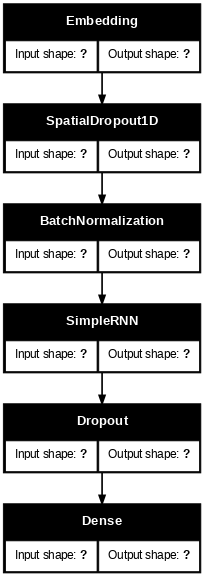

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 438ms/step - accuracy: 0.1709 - loss: 1.8496 - val_accuracy: 0.2508 - val_loss: 1.7384
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 238ms/step - accuracy: 0.2261 - loss: 1.7658 - val_accuracy: 0.2929 - val_loss: 1.7269
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 239ms/step - accuracy: 0.2873 - loss: 1.7063 - val_accuracy: 0.2929 - val_loss: 1.7274
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 246ms/step - accuracy: 0.3302 - loss: 1.6516 - val_accuracy: 0.2929 - val_loss: 1.7397
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 245ms/step - accuracy: 0.3787 - loss: 1.5922 - val_accuracy: 0.2929 - val_loss: 1.7645
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 244ms/step - accuracy: 0.4086 - loss: 1.5296 - val_accuracy: 0.2934 - val_loss: 1.7941
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 244ms/step - accuracy: 0.4232 - loss: 1.4854 - val_accuracy: 0.2937 - val_loss: 1.8209
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 243ms/step - accuracy: 0.4478 - loss: 1.4438 - val_accur

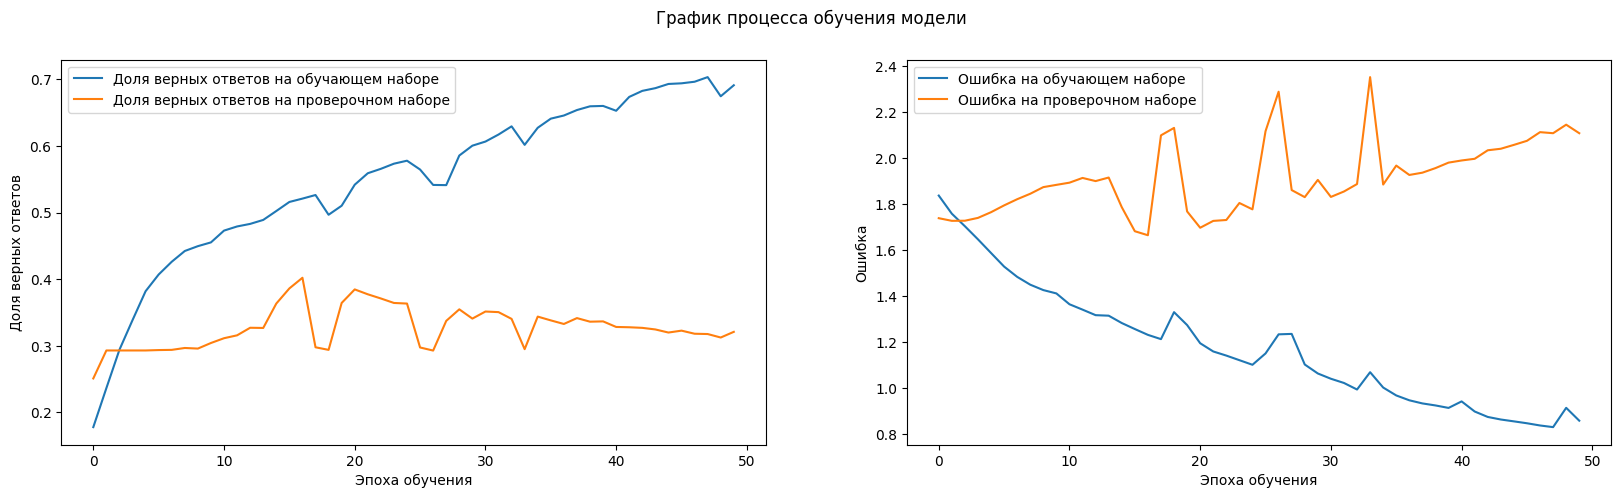

209/209 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step


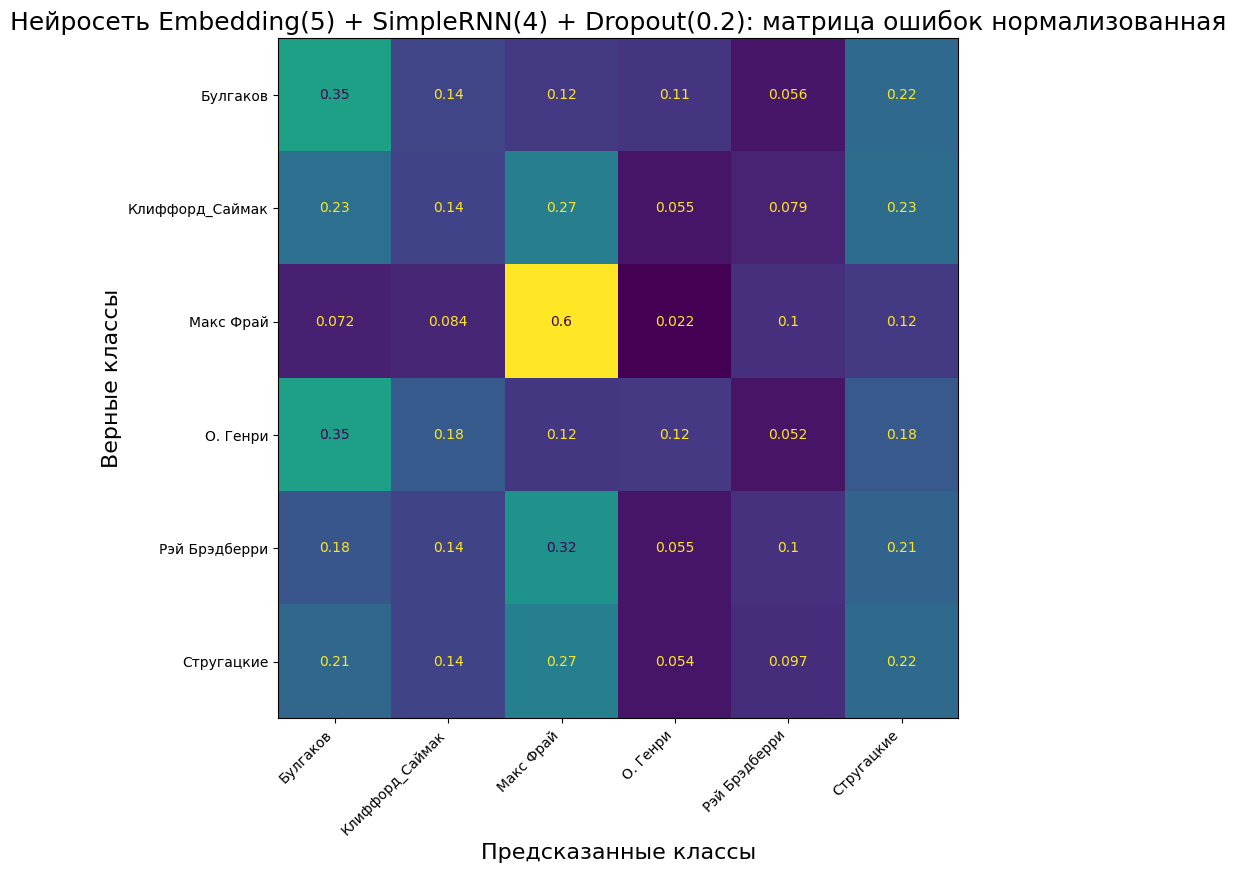

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(5) + SimpleRNN(4) + Dropout(0.2)
Класс: Булгаков              35% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       27% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(
Класс: Макс Фрай             60% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              35% сеть отнесла к классу Булгаков             - НЕВЕРНО :-(
Класс: Рэй Брэдберри         32% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(
Класс: Стругацкие            27% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(

Средняя точность распознавания:  26%


In [30]:
compile_train_eval_model(model_SimpleRNN_1,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=50,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(5) + SimpleRNN(4) + Dropout(0.2)')

#####**Исследование №2: Embedding(5) + SimpleRNN(20) + Dropout(0.2)**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_4                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_4 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

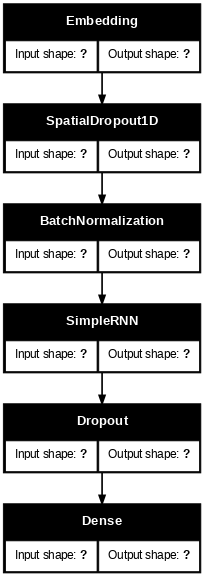

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 399ms/step - accuracy: 0.1773 - loss: 1.9623 - val_accuracy: 0.2929 - val_loss: 1.7862
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - accuracy: 0.2752 - loss: 1.7583 - val_accuracy: 0.2929 - val_loss: 1.9692
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 246ms/step - accuracy: 0.3701 - loss: 1.6043 - val_accuracy: 0.3196 - val_loss: 1.9944
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.4259 - loss: 1.4796 - val_accuracy: 0.3141 - val_loss: 2.0125
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 241ms/step - accuracy: 0.4054 - loss: 1.5443 - val_accuracy: 0.2866 - val_loss: 2.0760
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 244ms/step - accuracy: 0.4618 - loss: 1.3916 - val_accuracy: 0.2764 - val_loss: 2.1025
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 245ms/step - accuracy: 0.4836 - loss: 1.3476 - val_accuracy: 0.2197 - val_loss: 2.2228
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 256ms/step - accuracy: 0.5183 - loss: 1.2644 - val_accur

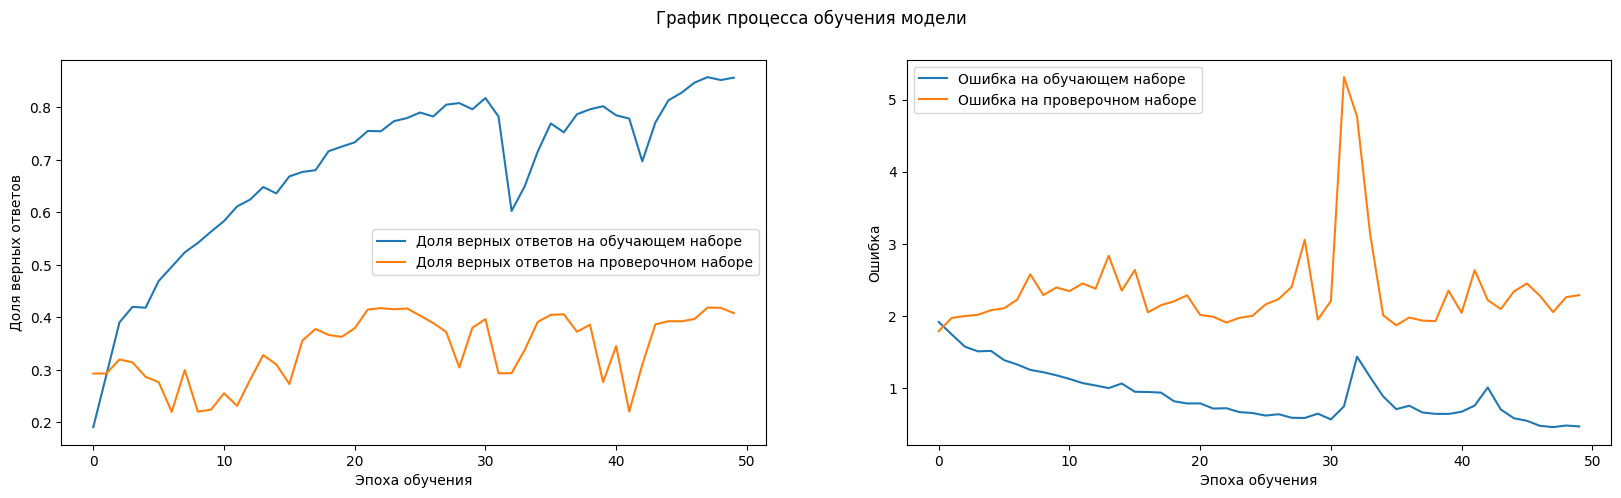

209/209 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step


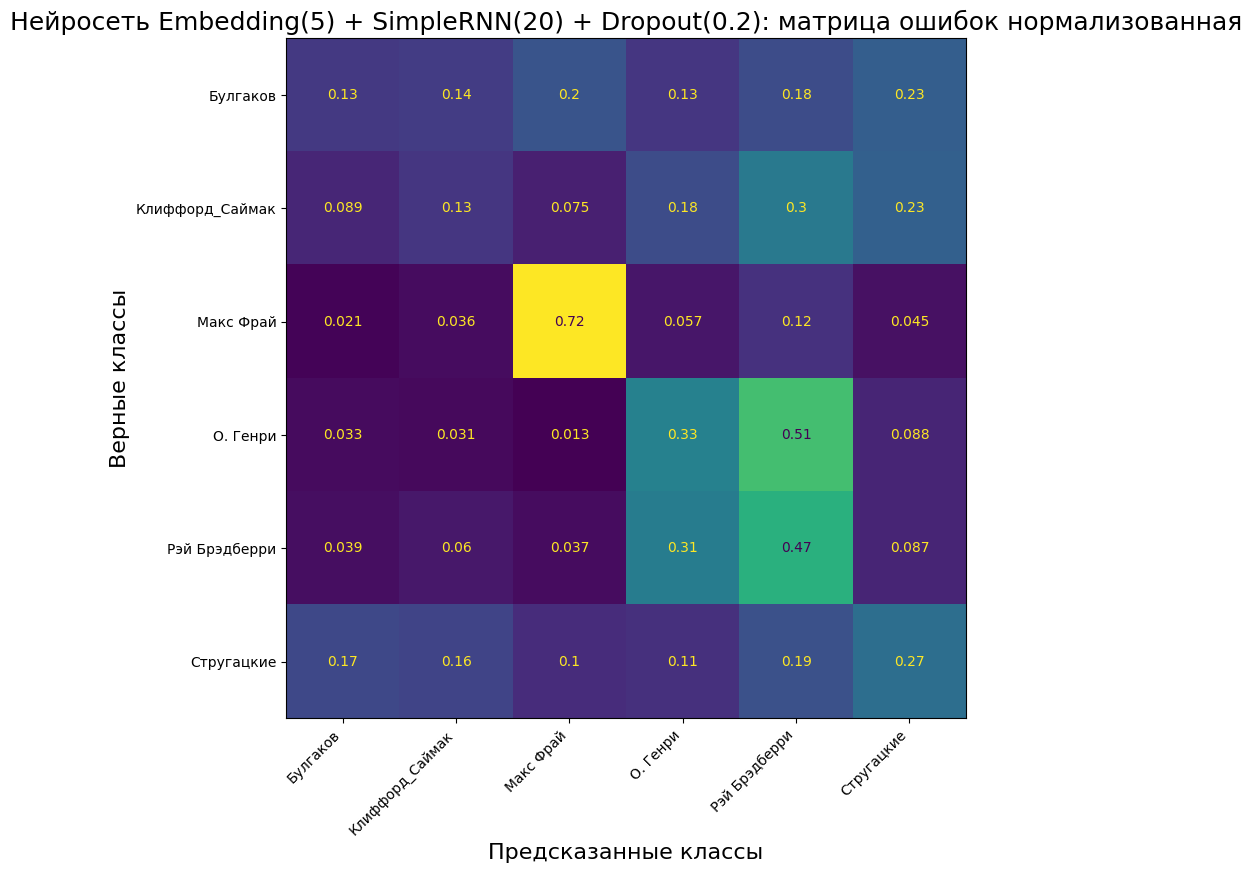

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(5) + SimpleRNN(20) + Dropout(0.2)
Класс: Булгаков              22% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       30% сеть отнесла к классу Рэй Брэдберри        - НЕВЕРНО :-(
Класс: Макс Фрай             72% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              51% сеть отнесла к классу Рэй Брэдберри        - НЕВЕРНО :-(
Класс: Рэй Брэдберри         47% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            27% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  34%


In [31]:
# Создание последовательной модели нейросети
model_SimpleRNN_2 = Sequential()

# Слой эмбеддинга преобразует каждое (индекс) в многомерный плотный вектор
# На входе указываются объем словаря, размерность вектора и длина входных данных
model_SimpleRNN_2.add(Embedding(VOCAB_SIZE, 5, input_length=WIN_SIZE))

# Слой регуляризации, "выключает" 1D карты объектов из эмбеддинг-векторов
model_SimpleRNN_2.add(SpatialDropout1D(0.2))
# Слой нормализации данных
model_SimpleRNN_2.add(BatchNormalization())
# Рекуррентный слой
model_SimpleRNN_2.add(SimpleRNN(20))
# Слой регуляризации Dropout для отдельных нейронов
model_SimpleRNN_2.add(Dropout(0.2))
# Выходной слой классификатора
model_SimpleRNN_2.add(Dense(CLASS_COUNT, activation='softmax')) # добавляем полносвязный слой на 6 нейронов, с функцией активации softmax на выходном слое

compile_train_eval_model(model_SimpleRNN_2,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=50,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(5) + SimpleRNN(20) + Dropout(0.2)')

#####**Исследование №3: Embedding(100) + SimpleRNN(20) + Dropout(0.2)**

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 1000, 100)         2000000   
_________________________________________________________________
spatial_dropout1d_1 (Spatial (None, 1000, 100)         0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 1000, 100)         400       
_________________________________________________________________
simple_rnn_1 (SimpleRNN)     (None, 20)                2420      
_________________________________________________________________
dropout_1 (Dropout)          (None, 20)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 6)                 126       
Total params: 2,002,946
Trainable params: 2,002,746
Non-trainable params: 200
__________________________________________

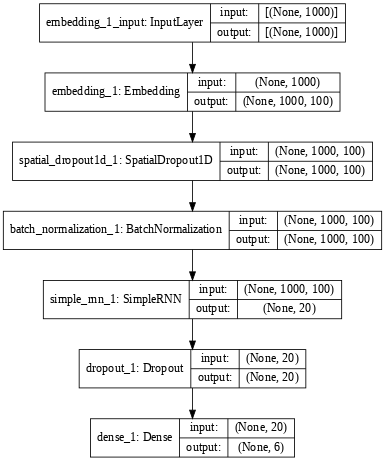

Epoch 1/50
35/35 [==============================] - 38s 1s/step - loss: 1.9554 - accuracy: 0.2185 - val_loss: 1.7289 - val_accuracy: 0.2924
Epoch 2/50
35/35 [==============================] - 36s 1s/step - loss: 1.6401 - accuracy: 0.3471 - val_loss: 1.9453 - val_accuracy: 0.2929
Epoch 3/50
35/35 [==============================] - 36s 1s/step - loss: 1.4409 - accuracy: 0.4573 - val_loss: 2.5432 - val_accuracy: 0.2939
Epoch 4/50
35/35 [==============================] - 36s 1s/step - loss: 1.2476 - accuracy: 0.5410 - val_loss: 2.8803 - val_accuracy: 0.2957
Epoch 5/50
35/35 [==============================] - 36s 1s/step - loss: 1.0799 - accuracy: 0.6147 - val_loss: 3.1740 - val_accuracy: 0.3011
Epoch 6/50
35/35 [==============================] - 36s 1s/step - loss: 0.9469 - accuracy: 0.6675 - val_loss: 3.3348 - val_accuracy: 0.3029
Epoch 7/50
35/35 [==============================] - 36s 1s/step - loss: 0.8430 - accuracy: 0.7110 - val_loss: 3.6689 - val_accuracy: 0.3075
Epoch 8/50
35/35 [==

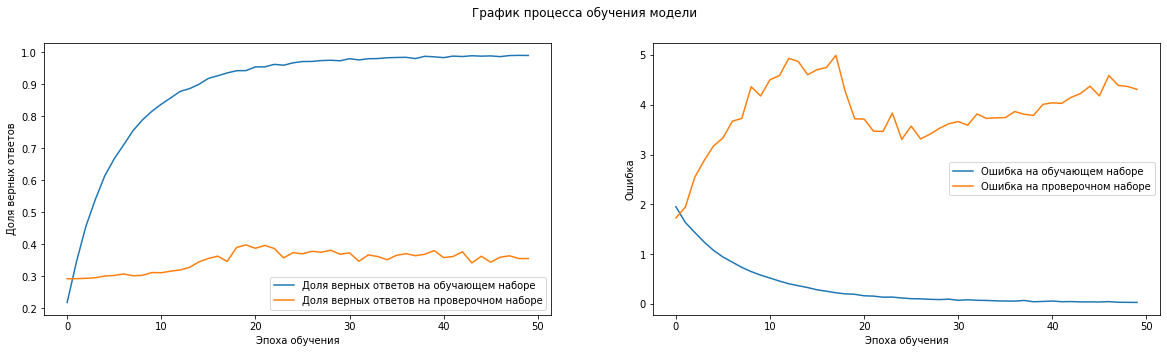

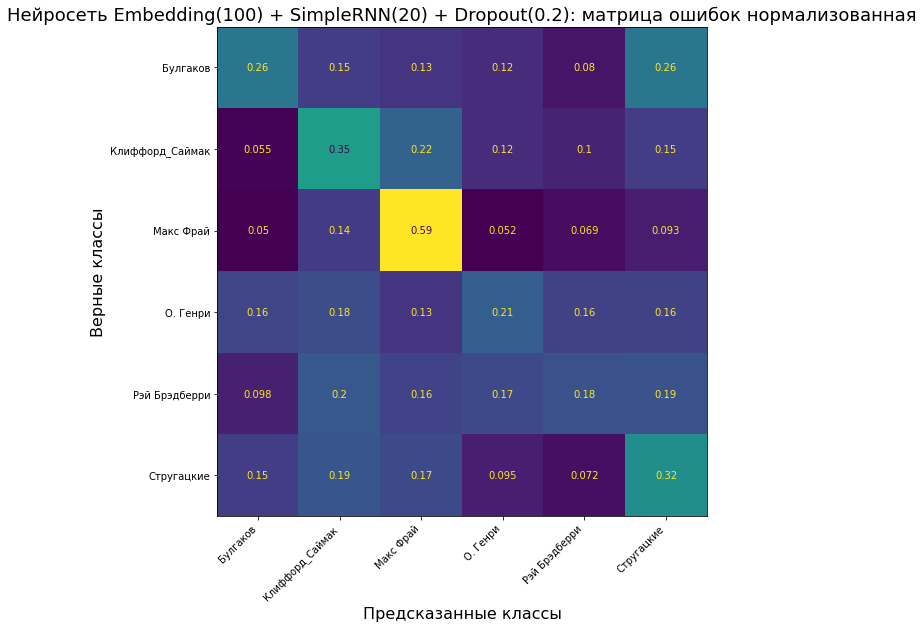

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(100) + SimpleRNN(20) + Dropout(0.2)
Класс: Булгаков              26% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       35% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             59% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              21% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         20% сеть отнесла к классу Клиффорд_Саймак      - НЕВЕРНО :-(
Класс: Стругацкие            32% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  32%


In [ ]:
# Создание последовательной модели нейросети
model_SimpleRNN_3 = Sequential()

# Слой эмбеддинга преобразует каждое (индекс) в многомерный плотный вектор
# На входе указываются объем словаря, размерность вектора и длина входных данных
model_SimpleRNN_3.add(Embedding(VOCAB_SIZE, 100, input_length=WIN_SIZE))

# Слой регуляризации, "выключает" 1D карты объектов из эмбеддинг-векторов
model_SimpleRNN_3.add(SpatialDropout1D(0.2))
# Слой нормализации данных
model_SimpleRNN_3.add(BatchNormalization())
# Рекуррентный слой
model_SimpleRNN_3.add(SimpleRNN(20))
# Слой регуляризации Dropout для отдельных нейронов
model_SimpleRNN_3.add(Dropout(0.2))
# Выходной слой классификатора
model_SimpleRNN_3.add(Dense(CLASS_COUNT, activation='softmax')) # добавляем полносвязный слой на 6 нейронов, с функцией активации softmax на выходном слое

compile_train_eval_model(model_SimpleRNN_3,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=50,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(100) + SimpleRNN(20) + Dropout(0.2)')

#####**Исследование №4: Embedding(5) + SimpleRNN(20) + Dropout(0.4)**

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_2 (Embedding)      (None, 1000, 5)           100000    
_________________________________________________________________
spatial_dropout1d_2 (Spatial (None, 1000, 5)           0         
_________________________________________________________________
batch_normalization_2 (Batch (None, 1000, 5)           20        
_________________________________________________________________
simple_rnn_2 (SimpleRNN)     (None, 20)                520       
_________________________________________________________________
dropout_2 (Dropout)          (None, 20)                0         
_________________________________________________________________
dense_2 (Dense)              (None, 6)                 126       
Total params: 100,666
Trainable params: 100,656
Non-trainable params: 10
_______________________________________________

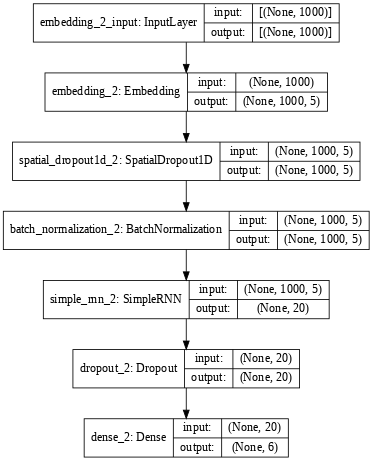

Epoch 1/50
35/35 [==============================] - 31s 860ms/step - loss: 1.9371 - accuracy: 0.1809 - val_loss: 1.7749 - val_accuracy: 0.2902
Epoch 2/50
35/35 [==============================] - 30s 847ms/step - loss: 1.8174 - accuracy: 0.2303 - val_loss: 1.7767 - val_accuracy: 0.2929
Epoch 3/50
35/35 [==============================] - 30s 858ms/step - loss: 1.7428 - accuracy: 0.2900 - val_loss: 1.7577 - val_accuracy: 0.2929
Epoch 4/50
35/35 [==============================] - 30s 852ms/step - loss: 1.6857 - accuracy: 0.3256 - val_loss: 1.9051 - val_accuracy: 0.2929
Epoch 5/50
35/35 [==============================] - 30s 850ms/step - loss: 1.6074 - accuracy: 0.3714 - val_loss: 2.0081 - val_accuracy: 0.2960
Epoch 6/50
35/35 [==============================] - 30s 863ms/step - loss: 1.5479 - accuracy: 0.3985 - val_loss: 1.8505 - val_accuracy: 0.3196
Epoch 7/50
35/35 [==============================] - 30s 852ms/step - loss: 1.5133 - accuracy: 0.4065 - val_loss: 1.8803 - val_accuracy: 0.3211

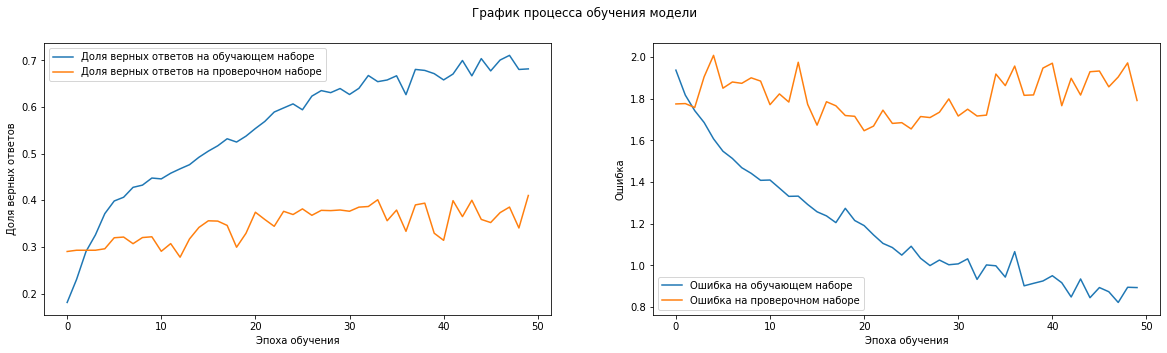

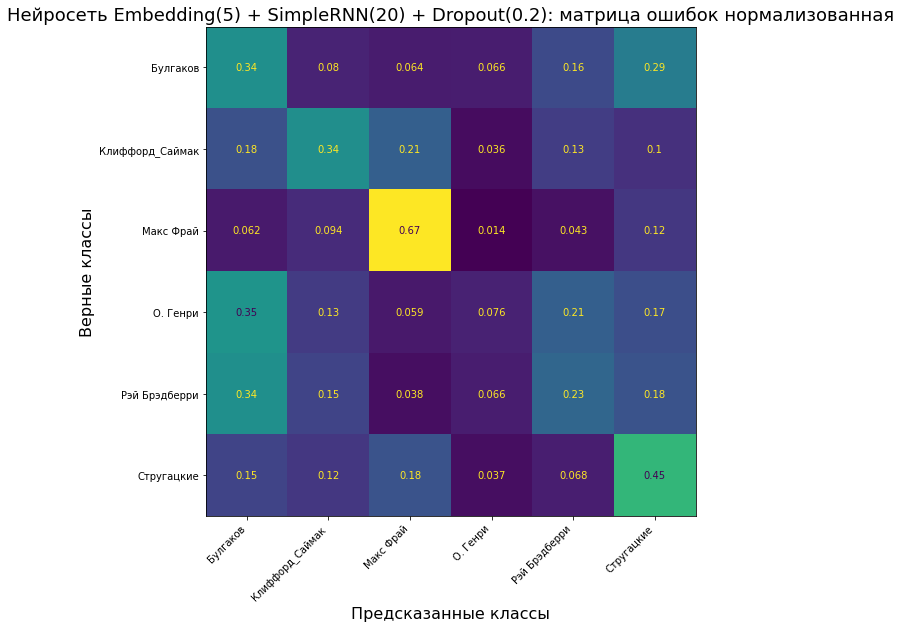

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(5) + SimpleRNN(20) + Dropout(0.2)
Класс: Булгаков              34% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       34% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             67% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              35% сеть отнесла к классу Булгаков             - НЕВЕРНО :-(
Класс: Рэй Брэдберри         34% сеть отнесла к классу Булгаков             - НЕВЕРНО :-(
Класс: Стругацкие            45% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  35%


In [ ]:
# Создание последовательной модели нейросети
model_SimpleRNN_4 = Sequential()

# Слой эмбеддинга преобразует каждое (индекс) в многомерный плотный вектор
# На входе указываются объем словаря, размерность вектора и длина входных данных
model_SimpleRNN_4.add(Embedding(VOCAB_SIZE, 5, input_length=WIN_SIZE))

# Слой регуляризации, "выключает" 1D карты объектов из эмбеддинг-векторов
model_SimpleRNN_4.add(SpatialDropout1D(0.4))
# Слой нормализации данных
model_SimpleRNN_4.add(BatchNormalization())
# Рекуррентный слой
model_SimpleRNN_4.add(SimpleRNN(20))
# Слой регуляризации Dropout для отдельных нейронов
model_SimpleRNN_4.add(Dropout(0.4))
# Выходной слой классификатора
model_SimpleRNN_4.add(Dense(CLASS_COUNT, activation='softmax')) # добавляем полносвязный слой на 6 нейронов, с функцией активации softmax на выходном слое

compile_train_eval_model(model_SimpleRNN_4,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=50,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(5) + SimpleRNN(20) + Dropout(0.2)')

#### GRU

#####**Исследование №5: Embedding(5) + GRU(4/0.2) + Dropout(0.2)**

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_4 (Embedding)      (None, 1000, 5)           100000    
_________________________________________________________________
spatial_dropout1d_4 (Spatial (None, 1000, 5)           0         
_________________________________________________________________
batch_normalization_8 (Batch (None, 1000, 5)           20        
_________________________________________________________________
gru (GRU)                    (None, 4)                 132       
_________________________________________________________________
dense_7 (Dense)              (None, 6)                 30        
Total params: 100,182
Trainable params: 100,172
Non-trainable params: 10
_________________________________________________________________


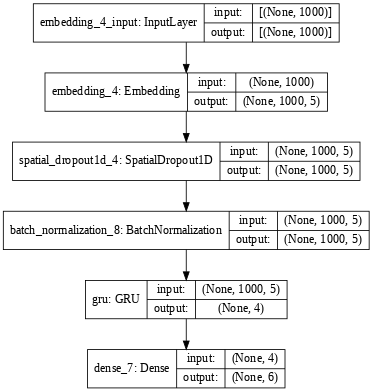

Epoch 1/50
35/35 [==============================] - 113s 3s/step - loss: 1.8579 - accuracy: 0.1293 - val_loss: 1.7817 - val_accuracy: 0.2930
Epoch 2/50
35/35 [==============================] - 110s 3s/step - loss: 1.7947 - accuracy: 0.1704 - val_loss: 1.7742 - val_accuracy: 0.2929
Epoch 3/50
35/35 [==============================] - 111s 3s/step - loss: 1.7641 - accuracy: 0.2478 - val_loss: 1.7671 - val_accuracy: 0.2929
Epoch 4/50
35/35 [==============================] - 111s 3s/step - loss: 1.7434 - accuracy: 0.3137 - val_loss: 1.7593 - val_accuracy: 0.2929
Epoch 5/50
35/35 [==============================] - 111s 3s/step - loss: 1.7231 - accuracy: 0.3287 - val_loss: 1.7513 - val_accuracy: 0.2929
Epoch 6/50
35/35 [==============================] - 110s 3s/step - loss: 1.6976 - accuracy: 0.3406 - val_loss: 1.7429 - val_accuracy: 0.2929
Epoch 7/50
35/35 [==============================] - 110s 3s/step - loss: 1.6672 - accuracy: 0.3494 - val_loss: 1.7354 - val_accuracy: 0.2929
Epoch 8/50
35

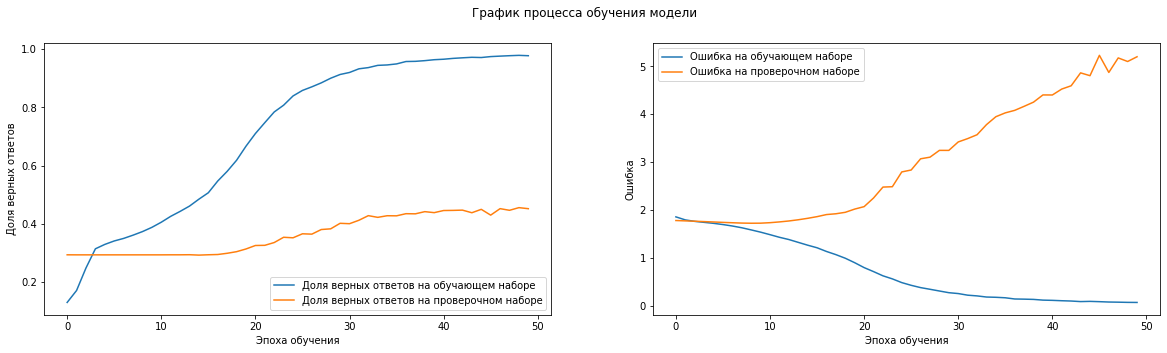

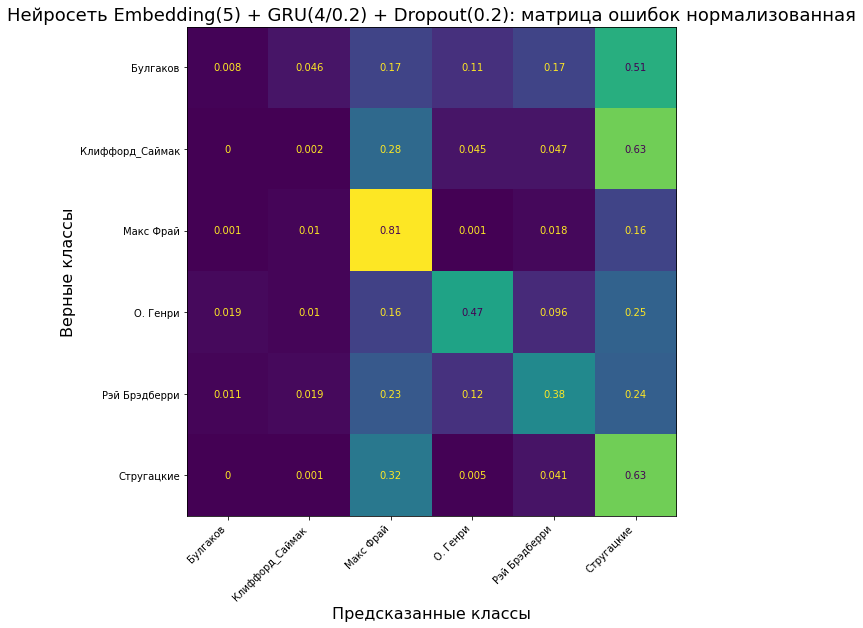

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(5) + GRU(4/0.2) + Dropout(0.2)
Класс: Булгаков              51% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       63% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Макс Фрай             81% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              47% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         38% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            63% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  38%


In [ ]:
model_GRU_1 = Sequential()
model_GRU_1.add(Embedding(VOCAB_SIZE, 5, input_length=WIN_SIZE))
model_GRU_1.add(SpatialDropout1D(0.2))
model_GRU_1.add(BatchNormalization())
# Рекуррентный слой GRU
model_GRU_1.add(GRU(4, dropout=0.2, recurrent_dropout=0.2, activation='relu'))
model_GRU_1.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_GRU_1,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=50,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(5) + GRU(4/0.2) + Dropout(0.2)')

#####**Исследование №6: Embedding(5) + GRU(40/0.4) + Dropout(0.2)**

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_5 (Embedding)      (None, 1000, 5)           100000    
_________________________________________________________________
spatial_dropout1d_5 (Spatial (None, 1000, 5)           0         
_________________________________________________________________
batch_normalization_9 (Batch (None, 1000, 5)           20        
_________________________________________________________________
gru_1 (GRU)                  (None, 40)                5640      
_________________________________________________________________
dense_8 (Dense)              (None, 6)                 246       
Total params: 105,906
Trainable params: 105,896
Non-trainable params: 10
_________________________________________________________________


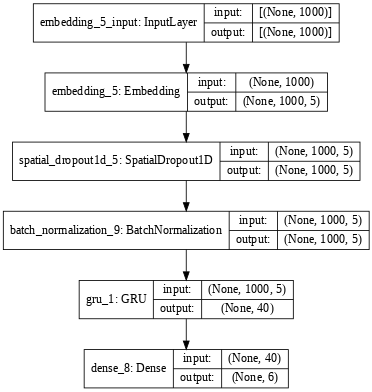

Epoch 1/50
35/35 [==============================] - 114s 3s/step - loss: 1.7147 - accuracy: 0.3111 - val_loss: 1.7489 - val_accuracy: 0.2929
Epoch 2/50
35/35 [==============================] - 111s 3s/step - loss: 1.6972 - accuracy: 0.3227 - val_loss: 1.7574 - val_accuracy: 0.2929
Epoch 3/50
35/35 [==============================] - 110s 3s/step - loss: 1.6004 - accuracy: 0.3308 - val_loss: 1.7563 - val_accuracy: 0.2929
Epoch 4/50
35/35 [==============================] - 110s 3s/step - loss: 1.6504 - accuracy: 0.3604 - val_loss: 1.7638 - val_accuracy: 0.2085
Epoch 5/50
35/35 [==============================] - 108s 3s/step - loss: 1.3791 - accuracy: 0.4135 - val_loss: 1.7713 - val_accuracy: 0.1647
Epoch 6/50
35/35 [==============================] - 109s 3s/step - loss: 1.2941 - accuracy: 0.4685 - val_loss: 1.7987 - val_accuracy: 0.1630
Epoch 7/50
35/35 [==============================] - 110s 3s/step - loss: 1.3939 - accuracy: 0.4959 - val_loss: 1.8155 - val_accuracy: 0.1826
Epoch 8/50
35

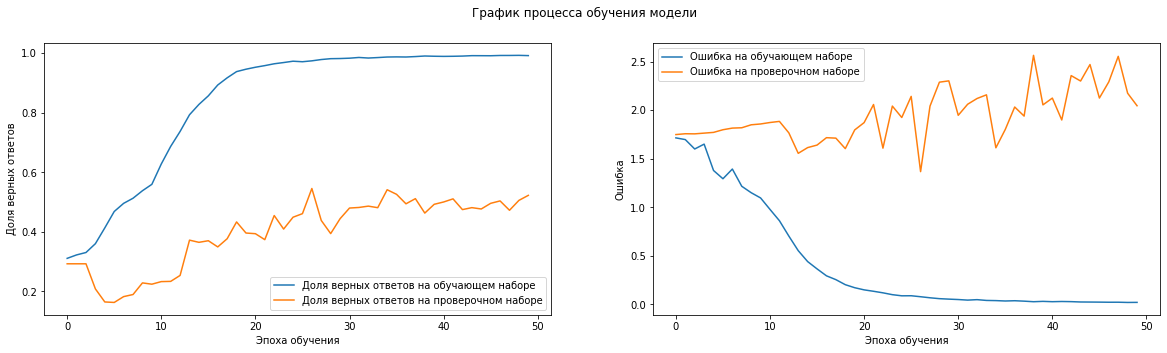

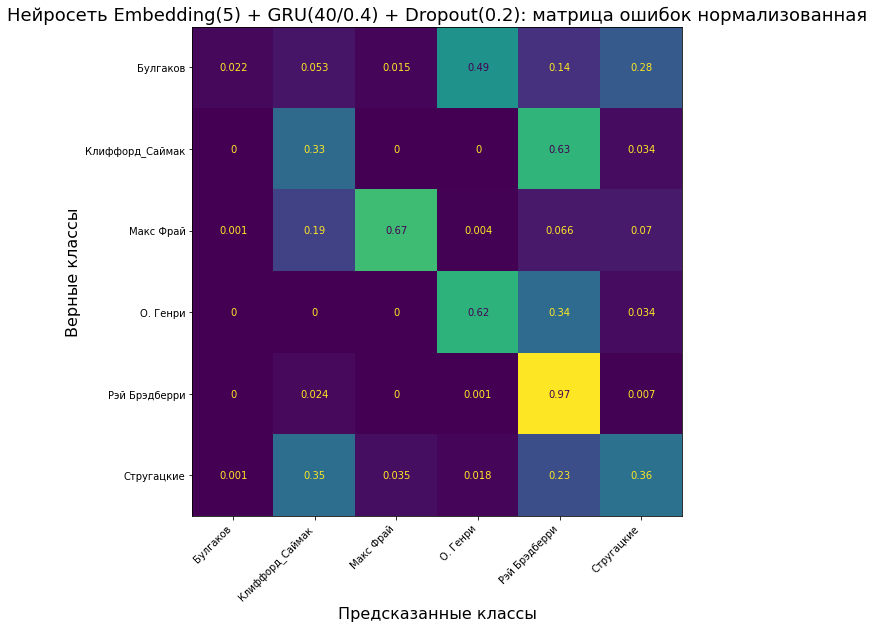

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(5) + GRU(40/0.4) + Dropout(0.2)
Класс: Булгаков              50% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       63% сеть отнесла к классу Рэй Брэдберри        - НЕВЕРНО :-(
Класс: Макс Фрай             67% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              62% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         97% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            36% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  50%


In [ ]:
model_GRU_2 = Sequential()
model_GRU_2.add(Embedding(VOCAB_SIZE, 5, input_length=WIN_SIZE))
model_GRU_2.add(SpatialDropout1D(0.2))
model_GRU_2.add(BatchNormalization())
# Рекуррентный слой GRU
model_GRU_2.add(GRU(40, dropout=0.4, recurrent_dropout=0.4, activation='relu'))
model_GRU_2.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_GRU_2,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=50,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(5) + GRU(40/0.4) + Dropout(0.2)')

#####**Исследование №7: Embedding(5) + GRU(80/0.2) + Dropout(0.2)**

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_2 (Embedding)      (None, 1000, 5)           100000    
_________________________________________________________________
spatial_dropout1d_2 (Spatial (None, 1000, 5)           0         
_________________________________________________________________
batch_normalization_2 (Batch (None, 1000, 5)           20        
_________________________________________________________________
gru_2 (GRU)                  (None, 80)                20880     
_________________________________________________________________
dense_2 (Dense)              (None, 6)                 486       
Total params: 121,386
Trainable params: 121,376
Non-trainable params: 10
_________________________________________________________________


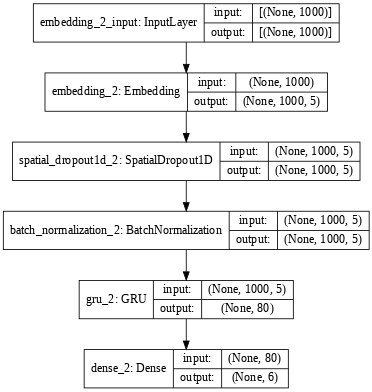

Epoch 1/50
35/35 [==============================] - 134s 4s/step - loss: 1.7677 - accuracy: 0.3138 - val_loss: 1.7546 - val_accuracy: 0.2929
Epoch 2/50
35/35 [==============================] - 131s 4s/step - loss: 1.6390 - accuracy: 0.3231 - val_loss: 1.7543 - val_accuracy: 0.2929
Epoch 3/50
35/35 [==============================] - 131s 4s/step - loss: 2.2099 - accuracy: 0.3673 - val_loss: 1.7723 - val_accuracy: 0.2317
Epoch 4/50
35/35 [==============================] - 131s 4s/step - loss: 1.4178 - accuracy: 0.4168 - val_loss: 1.7788 - val_accuracy: 0.2058
Epoch 5/50
35/35 [==============================] - 131s 4s/step - loss: 1.4586 - accuracy: 0.4504 - val_loss: 1.8278 - val_accuracy: 0.2022
Epoch 6/50
35/35 [==============================] - 131s 4s/step - loss: 1.2930 - accuracy: 0.4827 - val_loss: 1.8035 - val_accuracy: 0.2175
Epoch 7/50
35/35 [==============================] - 131s 4s/step - loss: 1.1503 - accuracy: 0.5249 - val_loss: 1.8055 - val_accuracy: 0.2249
Epoch 8/50
35

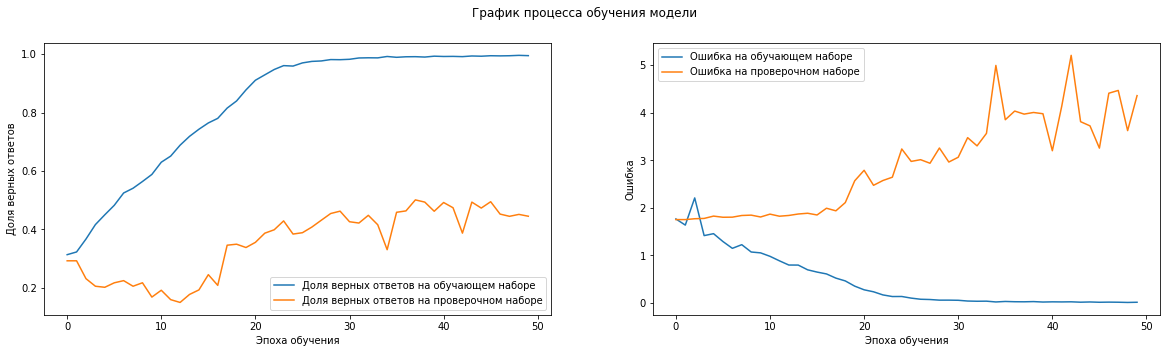

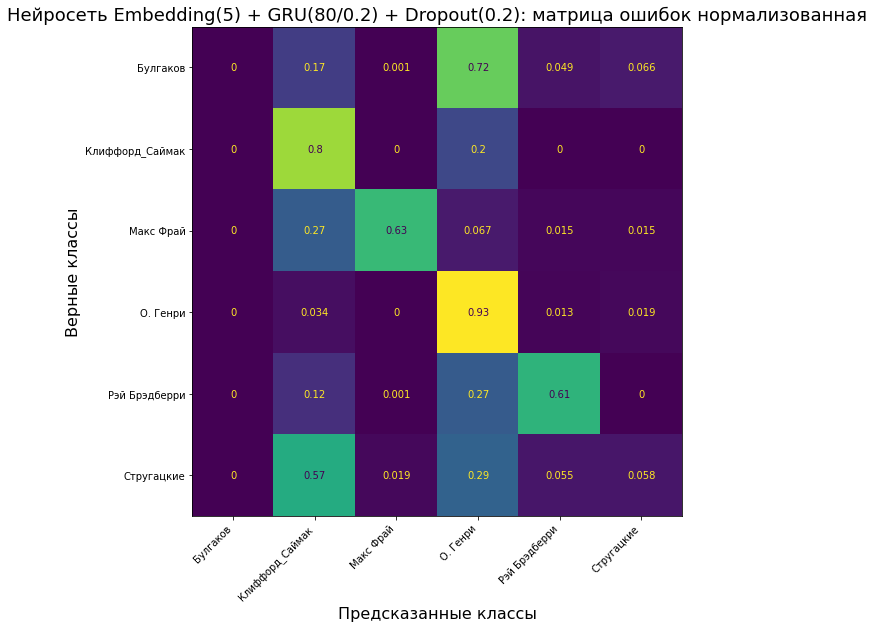

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(5) + GRU(80/0.2) + Dropout(0.2)
Класс: Булгаков              72% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       80% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             63% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              93% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         61% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            57% сеть отнесла к классу Клиффорд_Саймак      - НЕВЕРНО :-(

Средняя точность распознавания:  50%


In [ ]:
model_GRU_3 = Sequential()
model_GRU_3.add(Embedding(VOCAB_SIZE, 5, input_length=WIN_SIZE))
model_GRU_3.add(SpatialDropout1D(0.2))
model_GRU_3.add(BatchNormalization())
# Рекуррентный слой GRU
model_GRU_3.add(GRU(80, dropout=0.2, recurrent_dropout=0.2, activation='relu'))
model_GRU_3.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_GRU_3,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=50,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(5) + GRU(80/0.2) + Dropout(0.2)')

#### LSTM

#####**Исследование №8: Embedding(5) + LSTM(4) + Dropout(0.2)**

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_4 (Embedding)      (None, 1000, 5)           100000    
_________________________________________________________________
spatial_dropout1d_4 (Spatial (None, 1000, 5)           0         
_________________________________________________________________
batch_normalization_4 (Batch (None, 1000, 5)           20        
_________________________________________________________________
lstm (LSTM)                  (None, 4)                 160       
_________________________________________________________________
dense_4 (Dense)              (None, 6)                 30        
Total params: 100,210
Trainable params: 100,200
Non-trainable params: 10
_________________________________________________________________


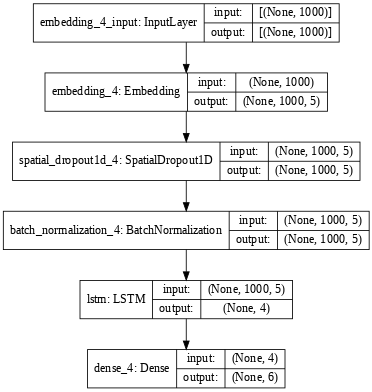

Epoch 1/100
35/35 [==============================] - 8s 73ms/step - loss: 1.7717 - accuracy: 0.2269 - val_loss: 1.7779 - val_accuracy: 0.2929
Epoch 2/100
35/35 [==============================] - 2s 62ms/step - loss: 1.7035 - accuracy: 0.3326 - val_loss: 1.7623 - val_accuracy: 0.2929
Epoch 3/100
35/35 [==============================] - 2s 62ms/step - loss: 1.6397 - accuracy: 0.3543 - val_loss: 1.7491 - val_accuracy: 0.2929
Epoch 4/100
35/35 [==============================] - 2s 62ms/step - loss: 1.5743 - accuracy: 0.3787 - val_loss: 1.7482 - val_accuracy: 0.2929
Epoch 5/100
35/35 [==============================] - 2s 63ms/step - loss: 1.5003 - accuracy: 0.4147 - val_loss: 1.8033 - val_accuracy: 0.2929
Epoch 6/100
35/35 [==============================] - 2s 63ms/step - loss: 1.4113 - accuracy: 0.4502 - val_loss: 1.8334 - val_accuracy: 0.3256
Epoch 7/100
35/35 [==============================] - 2s 62ms/step - loss: 1.3141 - accuracy: 0.4938 - val_loss: 1.7654 - val_accuracy: 0.3540
Epoch 

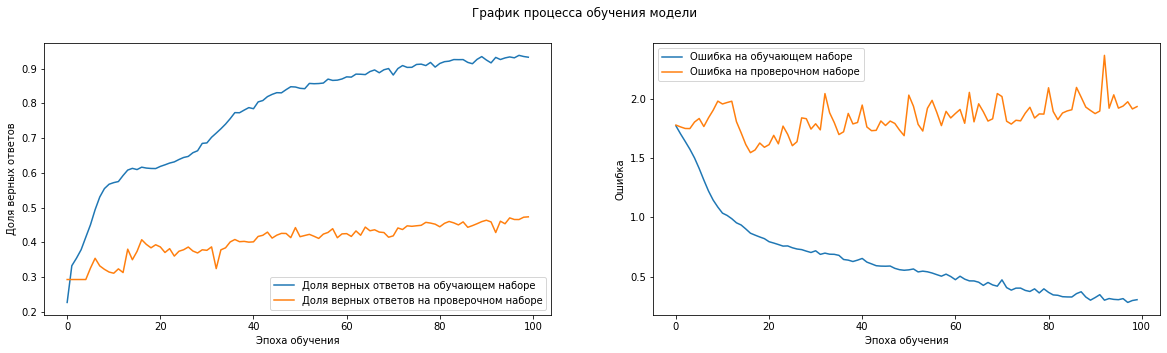

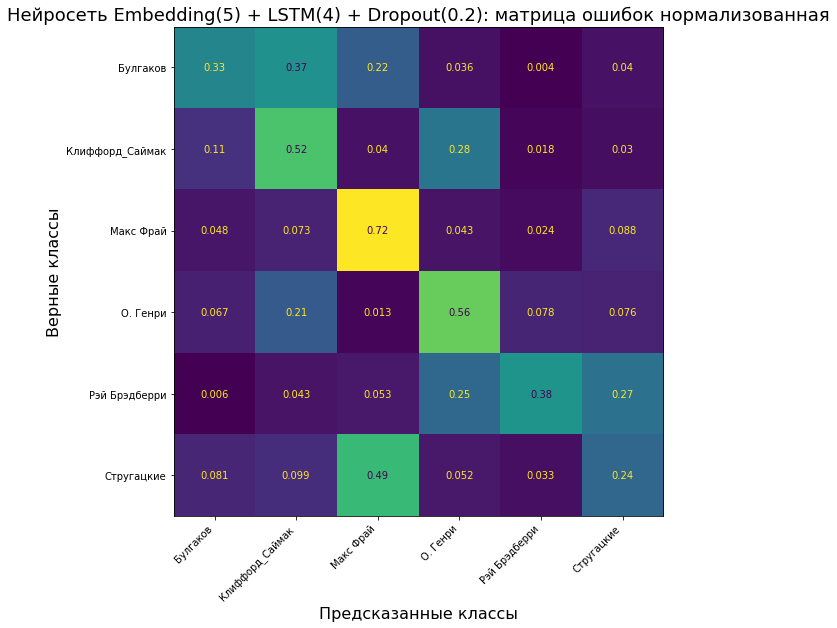

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(5) + LSTM(4) + Dropout(0.2)
Класс: Булгаков              37% сеть отнесла к классу Клиффорд_Саймак      - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       52% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             72% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              56% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         38% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            49% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(

Средняя точность распознавания:  46%


In [ ]:
model_LSTM_1 = Sequential()
model_LSTM_1.add(Embedding(VOCAB_SIZE, 5, input_length=WIN_SIZE))
model_LSTM_1.add(SpatialDropout1D(0.2))
model_LSTM_1.add(BatchNormalization())
# Рекуррентный слой LSTM
model_LSTM_1.add(LSTM(4))
model_LSTM_1.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_LSTM_1,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(5) + LSTM(4) + Dropout(0.2)')

#####**Исследование №9: Embedding(5) + LSTM(20) + Dropout(0.2)**

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_5 (Embedding)      (None, 1000, 5)           100000    
_________________________________________________________________
spatial_dropout1d_5 (Spatial (None, 1000, 5)           0         
_________________________________________________________________
batch_normalization_5 (Batch (None, 1000, 5)           20        
_________________________________________________________________
lstm_1 (LSTM)                (None, 20)                2080      
_________________________________________________________________
dense_5 (Dense)              (None, 6)                 126       
Total params: 102,226
Trainable params: 102,216
Non-trainable params: 10
_________________________________________________________________


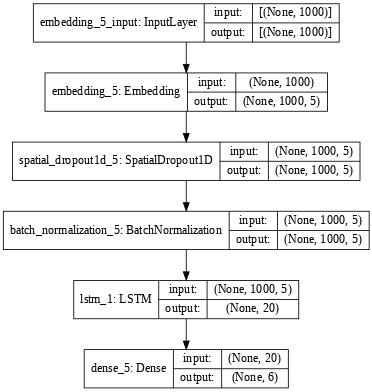

Epoch 1/100
35/35 [==============================] - 5s 83ms/step - loss: 1.6791 - accuracy: 0.3219 - val_loss: 1.9053 - val_accuracy: 0.2929
Epoch 2/100
35/35 [==============================] - 2s 71ms/step - loss: 1.3736 - accuracy: 0.4817 - val_loss: 1.8182 - val_accuracy: 0.1956
Epoch 3/100
35/35 [==============================] - 2s 70ms/step - loss: 1.2186 - accuracy: 0.5646 - val_loss: 1.8704 - val_accuracy: 0.2003
Epoch 4/100
35/35 [==============================] - 2s 69ms/step - loss: 1.1402 - accuracy: 0.6063 - val_loss: 1.8818 - val_accuracy: 0.1714
Epoch 5/100
35/35 [==============================] - 2s 71ms/step - loss: 1.0320 - accuracy: 0.6511 - val_loss: 1.9140 - val_accuracy: 0.1295
Epoch 6/100
35/35 [==============================] - 2s 70ms/step - loss: 0.9165 - accuracy: 0.6851 - val_loss: 1.9086 - val_accuracy: 0.1554
Epoch 7/100
35/35 [==============================] - 2s 70ms/step - loss: 0.8271 - accuracy: 0.7103 - val_loss: 2.7989 - val_accuracy: 0.2015
Epoch 

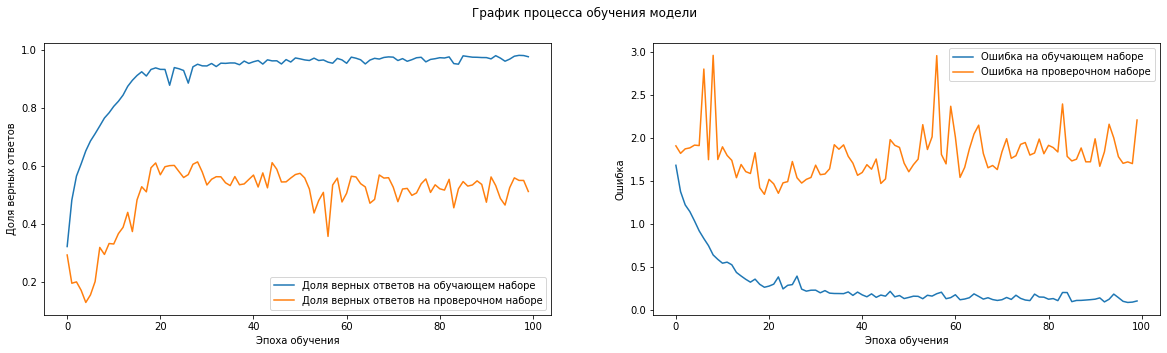

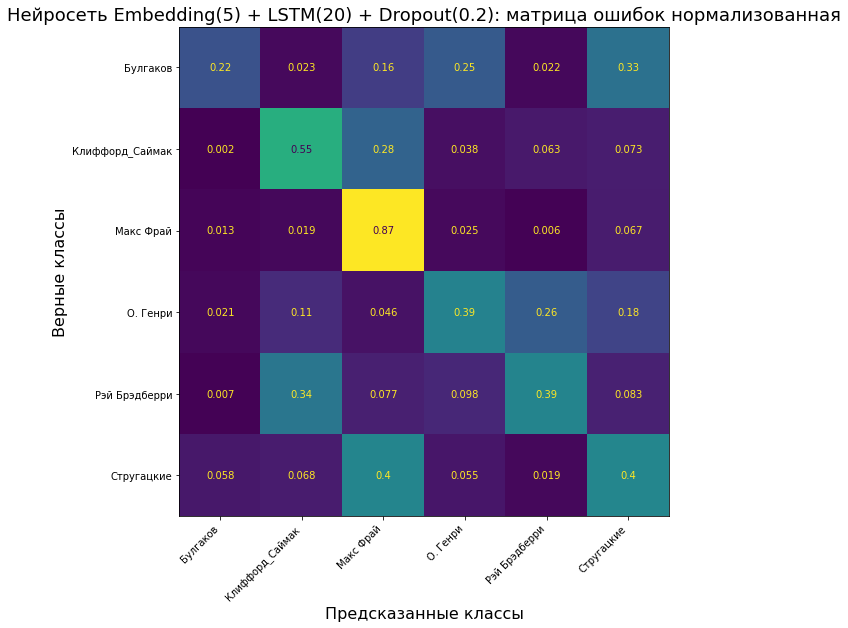

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(5) + LSTM(20) + Dropout(0.2)
Класс: Булгаков              33% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       55% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             87% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              39% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         39% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            40% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  47%


In [ ]:
model_LSTM_2 = Sequential() # создаём последовательную модель нейросети
model_LSTM_2.add(Embedding(VOCAB_SIZE, 5, input_length=WIN_SIZE))
model_LSTM_2.add(SpatialDropout1D(0.2))
model_LSTM_2.add(BatchNormalization())
# Рекуррентный слой LSTM
model_LSTM_2.add(LSTM(20))
model_LSTM_2.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_LSTM_2,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(5) + LSTM(20) + Dropout(0.2)')

#####**Исследование №10: Embedding(5) + LSTM(100) + Dropout(0.2)**

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_6 (Embedding)      (None, 1000, 5)           100000    
_________________________________________________________________
spatial_dropout1d_6 (Spatial (None, 1000, 5)           0         
_________________________________________________________________
batch_normalization_6 (Batch (None, 1000, 5)           20        
_________________________________________________________________
lstm_2 (LSTM)                (None, 100)               42400     
_________________________________________________________________
dense_6 (Dense)              (None, 6)                 606       
Total params: 143,026
Trainable params: 143,016
Non-trainable params: 10
_________________________________________________________________


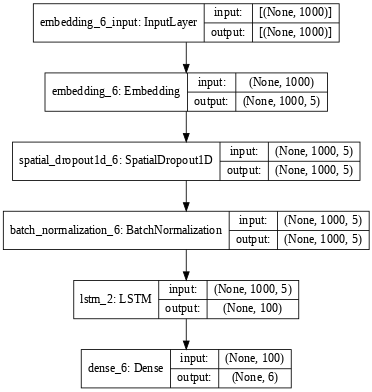

Epoch 1/100
35/35 [==============================] - 7s 165ms/step - loss: 1.5676 - accuracy: 0.3850 - val_loss: 1.7958 - val_accuracy: 0.2018
Epoch 2/100
35/35 [==============================] - 5s 152ms/step - loss: 1.3388 - accuracy: 0.4605 - val_loss: 2.0266 - val_accuracy: 0.2028
Epoch 3/100
35/35 [==============================] - 5s 153ms/step - loss: 1.2085 - accuracy: 0.5082 - val_loss: 1.5649 - val_accuracy: 0.3317
Epoch 4/100
35/35 [==============================] - 5s 153ms/step - loss: 1.0388 - accuracy: 0.5804 - val_loss: 2.0552 - val_accuracy: 0.1618
Epoch 5/100
35/35 [==============================] - 5s 153ms/step - loss: 0.8999 - accuracy: 0.6568 - val_loss: 2.2854 - val_accuracy: 0.1612
Epoch 6/100
35/35 [==============================] - 5s 153ms/step - loss: 0.8763 - accuracy: 0.6825 - val_loss: 1.7794 - val_accuracy: 0.2949
Epoch 7/100
35/35 [==============================] - 5s 153ms/step - loss: 0.8459 - accuracy: 0.7179 - val_loss: 1.8976 - val_accuracy: 0.1920

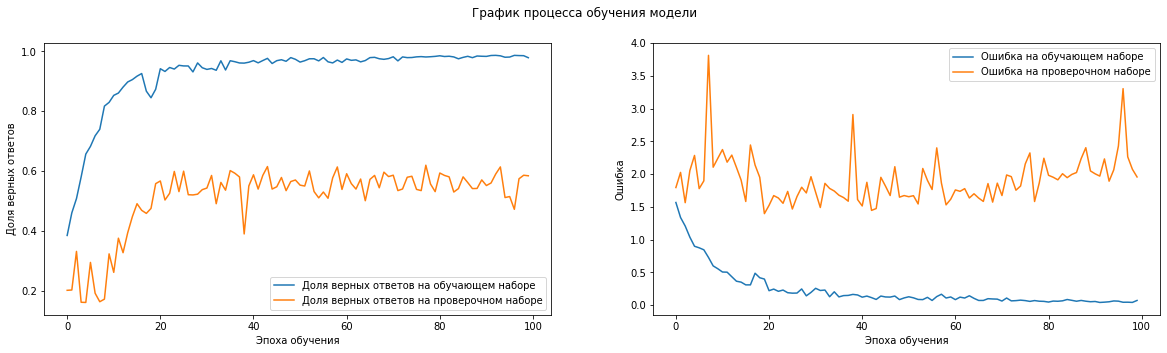

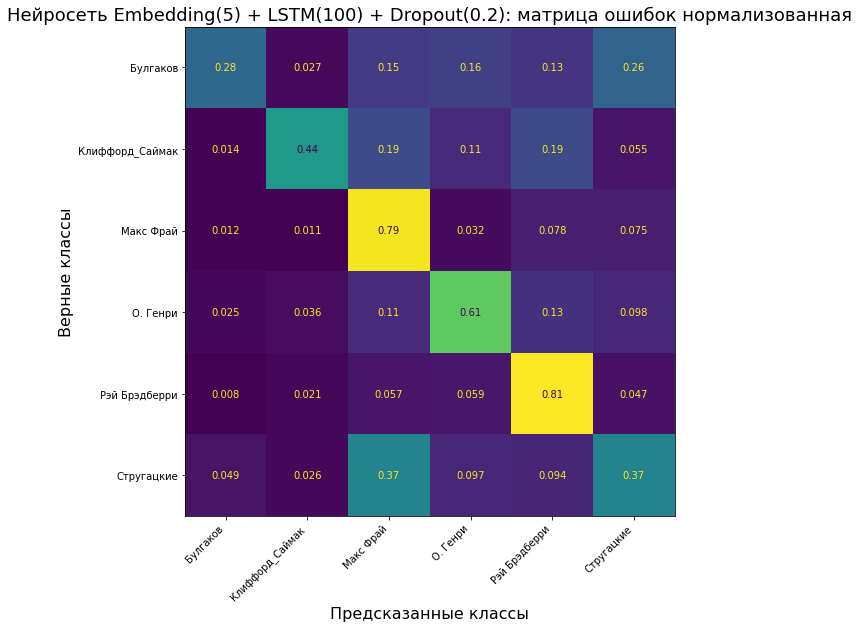

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(5) + LSTM(100) + Dropout(0.2)
Класс: Булгаков              28% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       44% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             79% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              61% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         81% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            37% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(

Средняя точность распознавания:  55%


In [ ]:
model_LSTM_3 = Sequential()
model_LSTM_3.add(Embedding(VOCAB_SIZE, 5, input_length=WIN_SIZE))
model_LSTM_3.add(SpatialDropout1D(0.2))
model_LSTM_3.add(BatchNormalization())
# Рекуррентный слой LSTM
model_LSTM_3.add(LSTM(100))
model_LSTM_3.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_LSTM_3,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(5) + LSTM(100) + Dropout(0.2)')

#####**Исследование №11: Embedding(5) + LSTM(4)x2 + Dropout(0.2)**

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_7 (Embedding)      (None, 1000, 5)           100000    
_________________________________________________________________
spatial_dropout1d_7 (Spatial (None, 1000, 5)           0         
_________________________________________________________________
batch_normalization_7 (Batch (None, 1000, 5)           20        
_________________________________________________________________
lstm_3 (LSTM)                (None, 1000, 4)           160       
_________________________________________________________________
lstm_4 (LSTM)                (None, 4)                 144       
_________________________________________________________________
dense_7 (Dense)              (None, 6)                 30        
Total params: 100,354
Trainable params: 100,344
Non-trainable params: 10
_______________________________________________

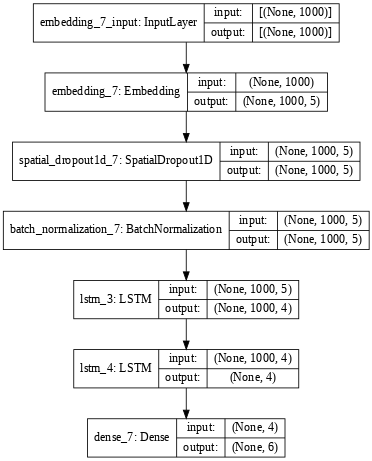

Epoch 1/100
35/35 [==============================] - 7s 115ms/step - loss: 1.7179 - accuracy: 0.3392 - val_loss: 1.7706 - val_accuracy: 0.2929
Epoch 2/100
35/35 [==============================] - 3s 96ms/step - loss: 1.5860 - accuracy: 0.4164 - val_loss: 1.8229 - val_accuracy: 0.2929
Epoch 3/100
35/35 [==============================] - 3s 96ms/step - loss: 1.4583 - accuracy: 0.4481 - val_loss: 1.9242 - val_accuracy: 0.2929
Epoch 4/100
35/35 [==============================] - 3s 96ms/step - loss: 1.3727 - accuracy: 0.4565 - val_loss: 2.0233 - val_accuracy: 0.2929
Epoch 5/100
35/35 [==============================] - 3s 96ms/step - loss: 1.3109 - accuracy: 0.4604 - val_loss: 2.1370 - val_accuracy: 0.2929
Epoch 6/100
35/35 [==============================] - 3s 95ms/step - loss: 1.2594 - accuracy: 0.4631 - val_loss: 2.2501 - val_accuracy: 0.2929
Epoch 7/100
35/35 [==============================] - 3s 97ms/step - loss: 1.2347 - accuracy: 0.4582 - val_loss: 2.3378 - val_accuracy: 0.2929
Epoch

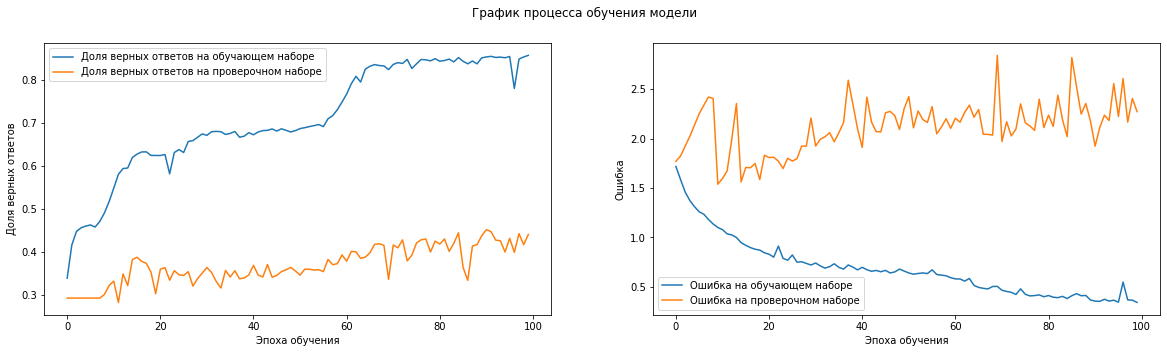

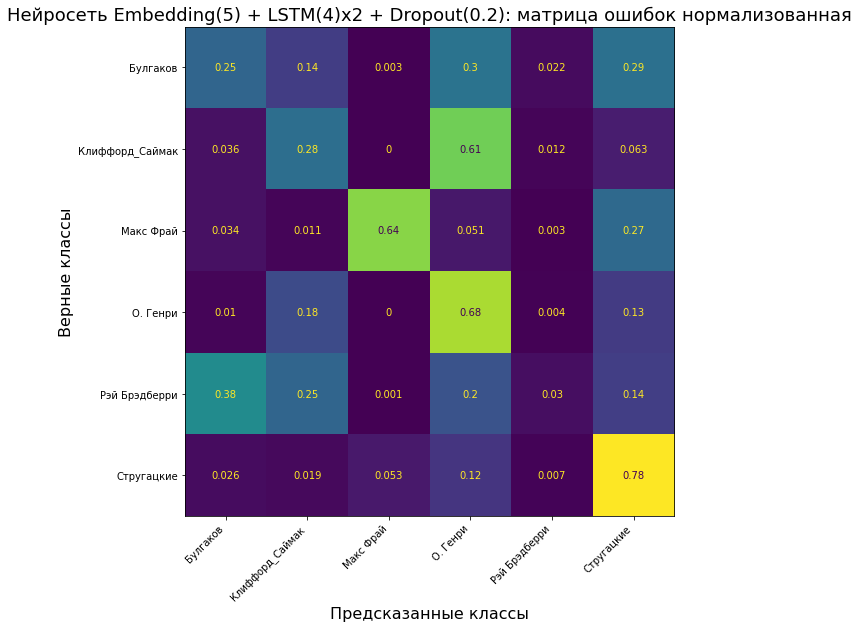

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(5) + LSTM(4)x2 + Dropout(0.2)
Класс: Булгаков              30% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       61% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(
Класс: Макс Фрай             64% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              68% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         38% сеть отнесла к классу Булгаков             - НЕВЕРНО :-(
Класс: Стругацкие            78% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  44%


In [ ]:
model_LSTM_4 = Sequential()
model_LSTM_4.add(Embedding(VOCAB_SIZE, 5, input_length=WIN_SIZE))
model_LSTM_4.add(SpatialDropout1D(0.2))
model_LSTM_4.add(BatchNormalization())
# Два рекуррентных слоя LSTM
model_LSTM_4.add(LSTM(4, return_sequences=True))
model_LSTM_4.add(LSTM(4))
model_LSTM_4.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_LSTM_4,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(5) + LSTM(4)x2 + Dropout(0.2)')

#####**Исследование №12: Embedding(200) + LSTM(4)x2 + Dropout(0.2)**

Model: "sequential_8"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_8 (Embedding)      (None, 1000, 200)         4000000   
_________________________________________________________________
spatial_dropout1d_8 (Spatial (None, 1000, 200)         0         
_________________________________________________________________
batch_normalization_8 (Batch (None, 1000, 200)         800       
_________________________________________________________________
lstm_5 (LSTM)                (None, 1000, 4)           3280      
_________________________________________________________________
lstm_6 (LSTM)                (None, 4)                 144       
_________________________________________________________________
dense_8 (Dense)              (None, 6)                 30        
Total params: 4,004,254
Trainable params: 4,003,854
Non-trainable params: 400
__________________________________________

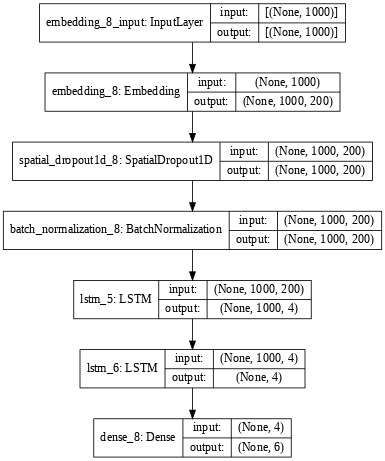

Epoch 1/100
35/35 [==============================] - 18s 423ms/step - loss: 1.7428 - accuracy: 0.3265 - val_loss: 1.7536 - val_accuracy: 0.2929
Epoch 2/100
35/35 [==============================] - 14s 408ms/step - loss: 1.6229 - accuracy: 0.4480 - val_loss: 1.7159 - val_accuracy: 0.3066
Epoch 3/100
35/35 [==============================] - 14s 408ms/step - loss: 1.4710 - accuracy: 0.5473 - val_loss: 1.7281 - val_accuracy: 0.2981
Epoch 4/100
35/35 [==============================] - 14s 405ms/step - loss: 1.3302 - accuracy: 0.6373 - val_loss: 1.8371 - val_accuracy: 0.1726
Epoch 5/100
35/35 [==============================] - 14s 406ms/step - loss: 1.2049 - accuracy: 0.7572 - val_loss: 1.7963 - val_accuracy: 0.1983
Epoch 6/100
35/35 [==============================] - 14s 404ms/step - loss: 1.0926 - accuracy: 0.7991 - val_loss: 1.8558 - val_accuracy: 0.1889
Epoch 7/100
35/35 [==============================] - 14s 408ms/step - loss: 0.9872 - accuracy: 0.8255 - val_loss: 1.8648 - val_accuracy:

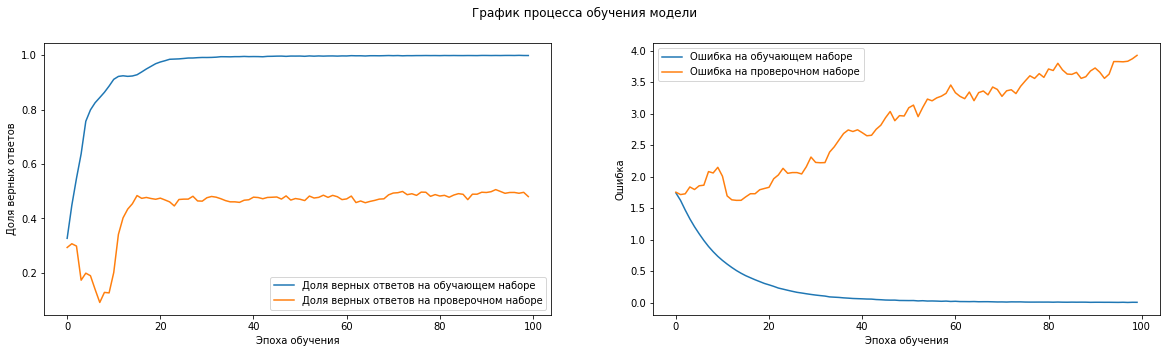

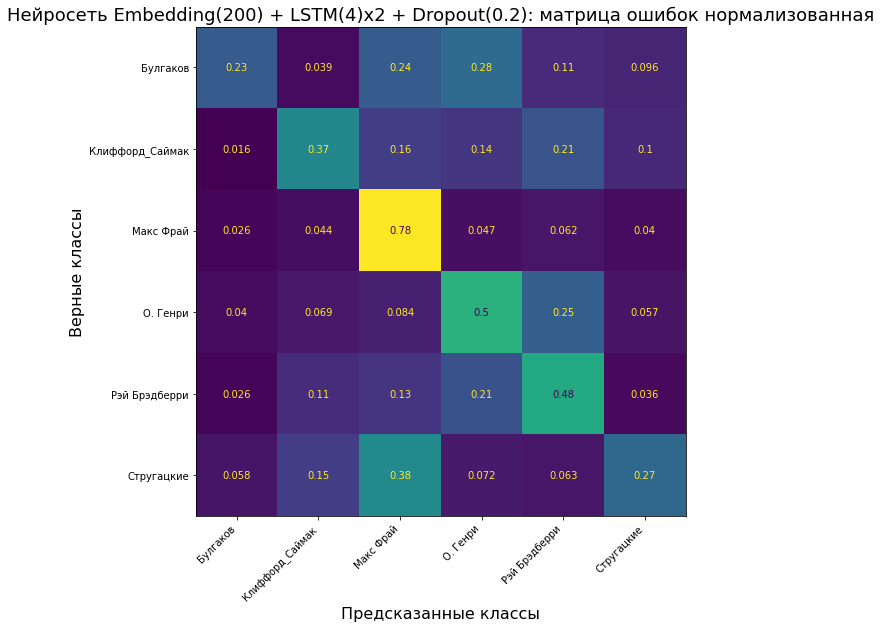

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(200) + LSTM(4)x2 + Dropout(0.2)
Класс: Булгаков              28% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       37% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             78% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              50% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         48% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            38% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(

Средняя точность распознавания:  44%


In [ ]:
model_LSTM_5 = Sequential()
model_LSTM_5.add(Embedding(VOCAB_SIZE, 200, input_length=WIN_SIZE))
model_LSTM_5.add(SpatialDropout1D(0.2))
model_LSTM_5.add(BatchNormalization())
# Два рекуррентных слоя LSTM
model_LSTM_5.add(LSTM(4, return_sequences=True))
model_LSTM_5.add(LSTM(4))
model_LSTM_5.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_LSTM_5,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(200) + LSTM(4)x2 + Dropout(0.2)')

#####**Исследование №13: Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200)**

Model: "sequential_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_9 (Embedding)      (None, 1000, 50)          1000000   
_________________________________________________________________
spatial_dropout1d_9 (Spatial (None, 1000, 50)          0         
_________________________________________________________________
batch_normalization_9 (Batch (None, 1000, 50)          200       
_________________________________________________________________
bidirectional (Bidirectional (None, 1000, 16)          3776      
_________________________________________________________________
bidirectional_1 (Bidirection (None, 1000, 16)          1600      
_________________________________________________________________
dropout_3 (Dropout)          (None, 1000, 16)          0         
_________________________________________________________________
batch_normalization_10 (Batc (None, 1000, 16)         

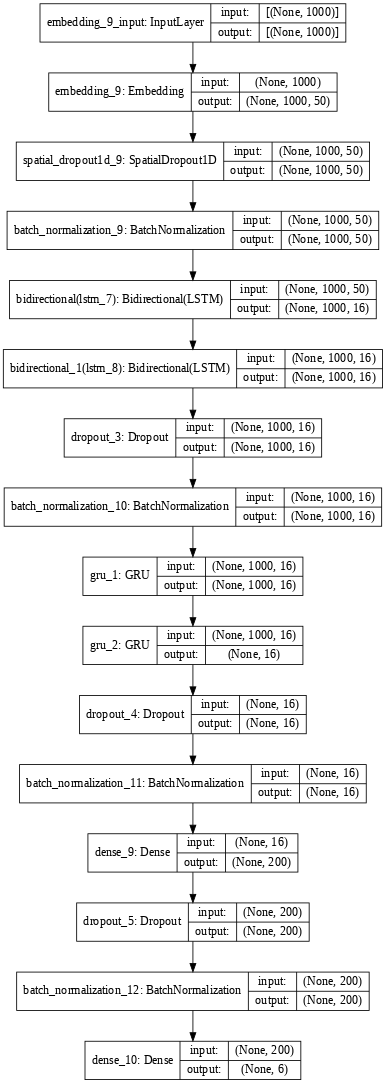

Epoch 1/100
35/35 [==============================] - 22s 394ms/step - loss: 2.0140 - accuracy: 0.2314 - val_loss: 1.7394 - val_accuracy: 0.2929
Epoch 2/100
35/35 [==============================] - 12s 353ms/step - loss: 1.7456 - accuracy: 0.3318 - val_loss: 1.7364 - val_accuracy: 0.2929
Epoch 3/100
35/35 [==============================] - 12s 355ms/step - loss: 1.4566 - accuracy: 0.4285 - val_loss: 1.8097 - val_accuracy: 0.1611
Epoch 4/100
35/35 [==============================] - 12s 353ms/step - loss: 1.1999 - accuracy: 0.5122 - val_loss: 1.8810 - val_accuracy: 0.1611
Epoch 5/100
35/35 [==============================] - 12s 351ms/step - loss: 1.0385 - accuracy: 0.5849 - val_loss: 1.9753 - val_accuracy: 0.1971
Epoch 6/100
35/35 [==============================] - 12s 352ms/step - loss: 0.9135 - accuracy: 0.6473 - val_loss: 2.2013 - val_accuracy: 0.2128
Epoch 7/100
35/35 [==============================] - 12s 352ms/step - loss: 0.7772 - accuracy: 0.7008 - val_loss: 2.5331 - val_accuracy:

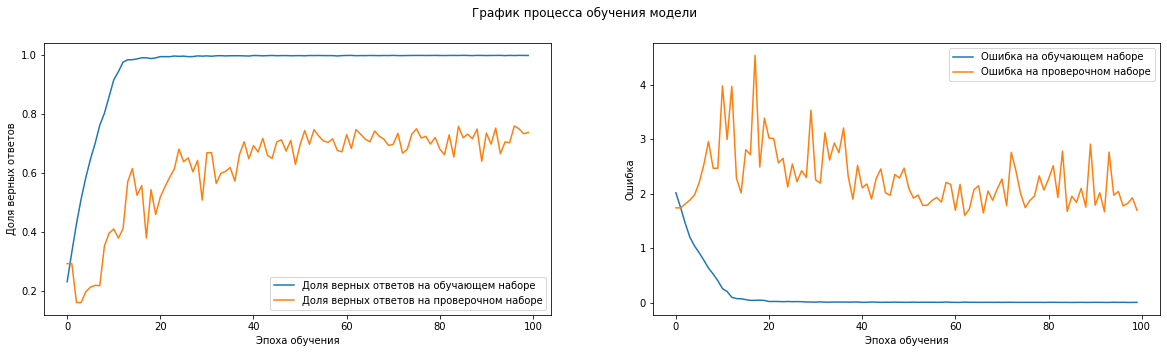

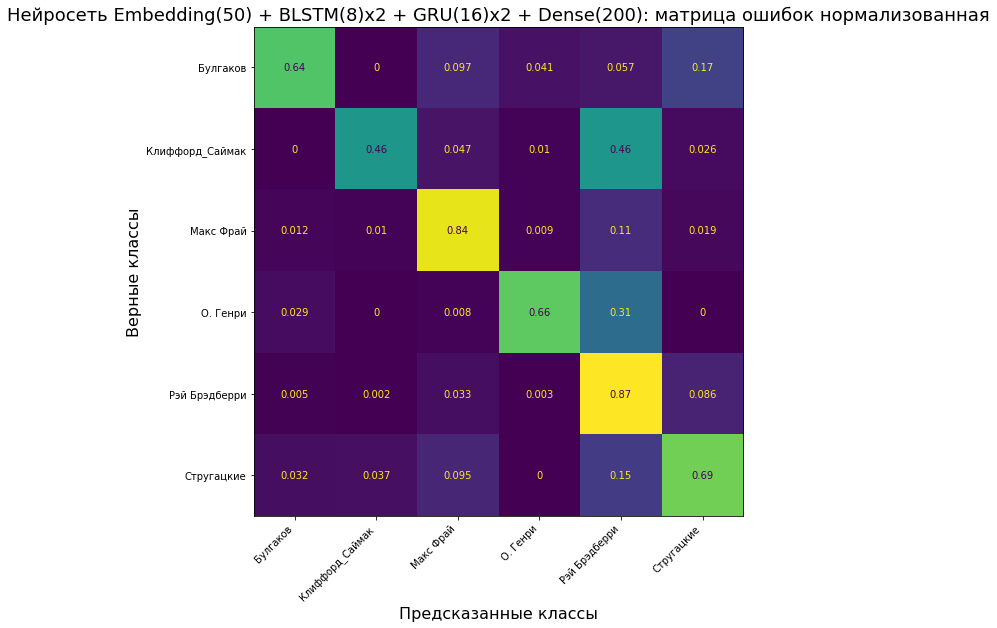

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200)
Класс: Булгаков              64% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       46% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             84% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              66% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         87% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            69% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  69%


In [ ]:
model_LSTM_6 = Sequential()
model_LSTM_6.add(Embedding(VOCAB_SIZE, 50, input_length=WIN_SIZE))
model_LSTM_6.add(SpatialDropout1D(0.4))
model_LSTM_6.add(BatchNormalization())
# Два двунаправленных рекуррентных слоя LSTM
model_LSTM_6.add(Bidirectional(LSTM(8, return_sequences=True)))
model_LSTM_6.add(Bidirectional(LSTM(8, return_sequences=True)))
model_LSTM_6.add(Dropout(0.3))
model_LSTM_6.add(BatchNormalization())
# Два рекуррентных слоя GRU
model_LSTM_6.add(GRU(16, return_sequences=True, reset_after=True))
model_LSTM_6.add(GRU(16, reset_after=True))
model_LSTM_6.add(Dropout(0.3))
model_LSTM_6.add(BatchNormalization())
# Дополнительный полносвязный слой
model_LSTM_6.add(Dense(200, activation='relu'))
model_LSTM_6.add(Dropout(0.3))
model_LSTM_6.add(BatchNormalization())
model_LSTM_6.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_LSTM_6,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200)')

#####**Исследование №14: Embedding(50) + BLSTM(8)x2 + Dropout(0.4, 0.3)**

Model: "sequential_10"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_10 (Embedding)     (None, 1000, 50)          1000000   
_________________________________________________________________
spatial_dropout1d_10 (Spatia (None, 1000, 50)          0         
_________________________________________________________________
batch_normalization_13 (Batc (None, 1000, 50)          200       
_________________________________________________________________
bidirectional_2 (Bidirection (None, 1000, 16)          3776      
_________________________________________________________________
bidirectional_3 (Bidirection (None, 16)                1600      
_________________________________________________________________
dropout_6 (Dropout)          (None, 16)                0         
_________________________________________________________________
dense_11 (Dense)             (None, 6)               

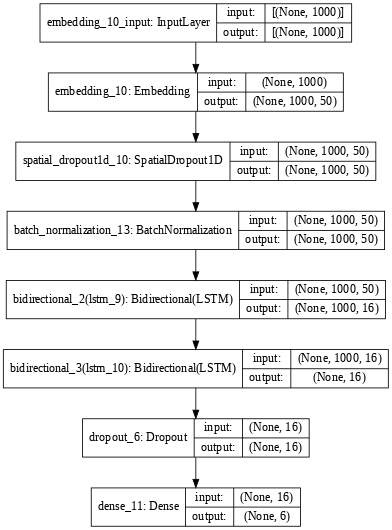

Epoch 1/100
35/35 [==============================] - 15s 302ms/step - loss: 1.6829 - accuracy: 0.3196 - val_loss: 1.7298 - val_accuracy: 0.2929
Epoch 2/100
35/35 [==============================] - 9s 257ms/step - loss: 1.3876 - accuracy: 0.4803 - val_loss: 1.7903 - val_accuracy: 0.3235
Epoch 3/100
35/35 [==============================] - 9s 256ms/step - loss: 1.0729 - accuracy: 0.6336 - val_loss: 1.7965 - val_accuracy: 0.2380
Epoch 4/100
35/35 [==============================] - 9s 258ms/step - loss: 0.8445 - accuracy: 0.7289 - val_loss: 2.1095 - val_accuracy: 0.1908
Epoch 5/100
35/35 [==============================] - 9s 257ms/step - loss: 0.6838 - accuracy: 0.7899 - val_loss: 2.2246 - val_accuracy: 0.2408
Epoch 6/100
35/35 [==============================] - 9s 256ms/step - loss: 0.5614 - accuracy: 0.8346 - val_loss: 2.1739 - val_accuracy: 0.2842
Epoch 7/100
35/35 [==============================] - 9s 256ms/step - loss: 0.4701 - accuracy: 0.8670 - val_loss: 2.4984 - val_accuracy: 0.234

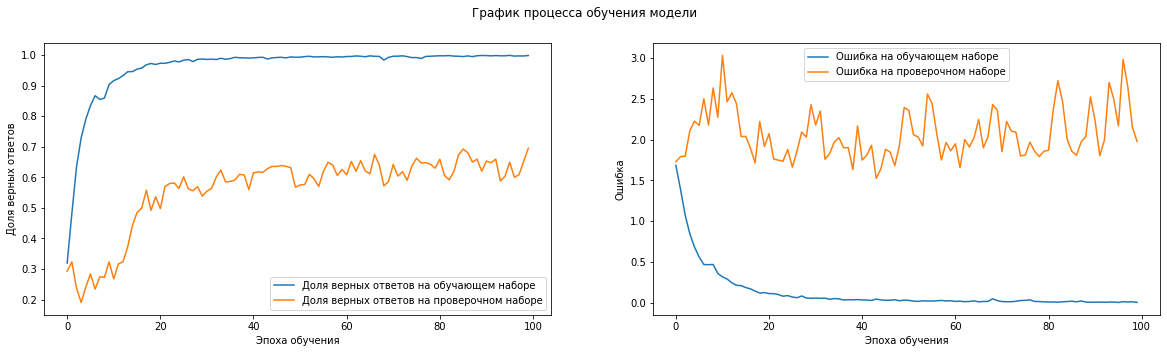

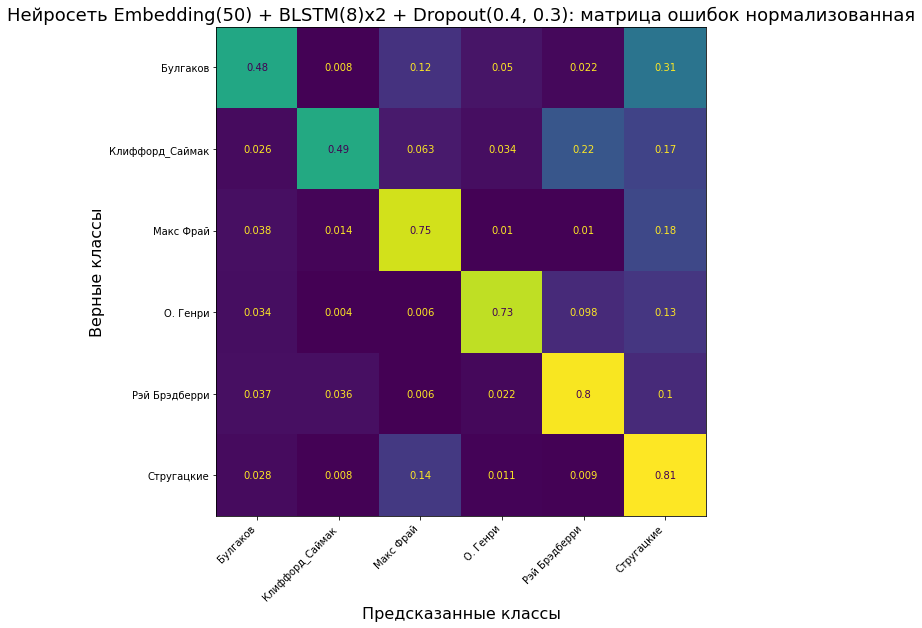

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(50) + BLSTM(8)x2 + Dropout(0.4, 0.3)
Класс: Булгаков              48% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       49% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             75% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              73% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         80% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            81% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  68%


In [ ]:
model_LSTM_7 = Sequential()
model_LSTM_7.add(Embedding(VOCAB_SIZE, 50, input_length=WIN_SIZE))
model_LSTM_7.add(SpatialDropout1D(0.4))
model_LSTM_7.add(BatchNormalization())
# Два двунаправленных рекуррентных слоя LSTM
model_LSTM_7.add(Bidirectional(LSTM(8, return_sequences=True)))
model_LSTM_7.add(Bidirectional(LSTM(8)))
model_LSTM_7.add(Dropout(0.3))
model_LSTM_7.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_LSTM_7,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(50) + BLSTM(8)x2 + Dropout(0.4, 0.3)')

#####**Исследование №15: Embedding(10) + LSTM(4) + Dense(100)**

Model: "sequential_11"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_11 (Embedding)     (None, 1000, 10)          200000    
_________________________________________________________________
spatial_dropout1d_11 (Spatia (None, 1000, 10)          0         
_________________________________________________________________
batch_normalization_14 (Batc (None, 1000, 10)          40        
_________________________________________________________________
lstm_11 (LSTM)               (None, 4)                 240       
_________________________________________________________________
dropout_7 (Dropout)          (None, 4)                 0         
_________________________________________________________________
batch_normalization_15 (Batc (None, 4)                 16        
_________________________________________________________________
dense_12 (Dense)             (None, 100)             

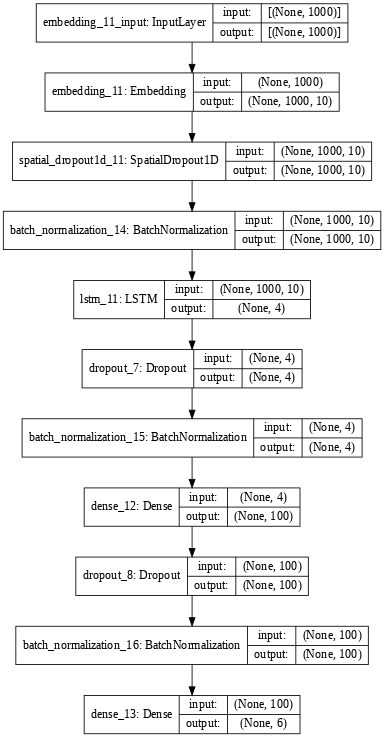

Epoch 1/100
89/89 [==============================] - 7s 58ms/step - loss: 2.0443 - accuracy: 0.2200 - val_loss: 1.7430 - val_accuracy: 0.2929
Epoch 2/100
89/89 [==============================] - 5s 53ms/step - loss: 1.8593 - accuracy: 0.2735 - val_loss: 1.7421 - val_accuracy: 0.2929
Epoch 3/100
89/89 [==============================] - 5s 53ms/step - loss: 1.7619 - accuracy: 0.3019 - val_loss: 1.7120 - val_accuracy: 0.2929
Epoch 4/100
89/89 [==============================] - 5s 55ms/step - loss: 1.6275 - accuracy: 0.3527 - val_loss: 1.6590 - val_accuracy: 0.3705
Epoch 5/100
89/89 [==============================] - 5s 55ms/step - loss: 1.4526 - accuracy: 0.4061 - val_loss: 1.6208 - val_accuracy: 0.3009
Epoch 6/100
89/89 [==============================] - 5s 53ms/step - loss: 1.3859 - accuracy: 0.4121 - val_loss: 1.5367 - val_accuracy: 0.3415
Epoch 7/100
89/89 [==============================] - 5s 53ms/step - loss: 1.3646 - accuracy: 0.4163 - val_loss: 1.5696 - val_accuracy: 0.3371
Epoch 

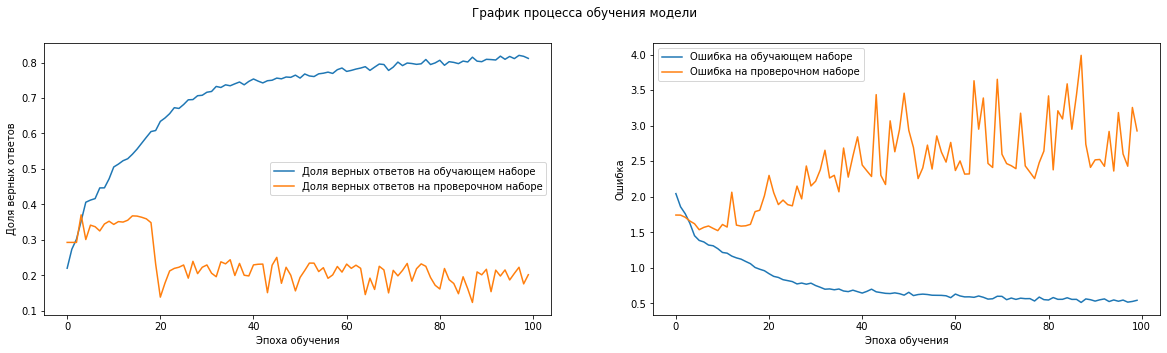

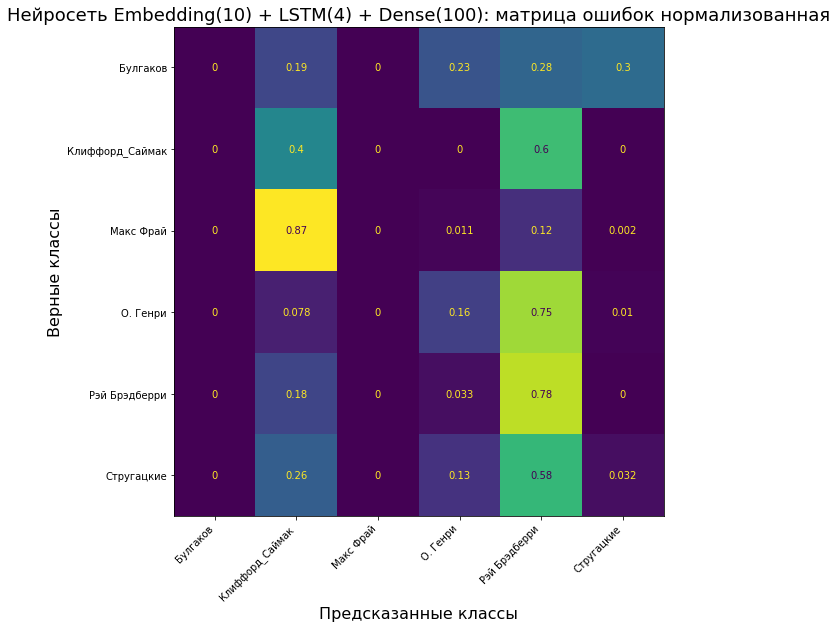

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(10) + LSTM(4) + Dense(100)
Класс: Булгаков              30% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       60% сеть отнесла к классу Рэй Брэдберри        - НЕВЕРНО :-(
Класс: Макс Фрай             87% сеть отнесла к классу Клиффорд_Саймак      - НЕВЕРНО :-(
Класс: О. Генри              75% сеть отнесла к классу Рэй Брэдберри        - НЕВЕРНО :-(
Класс: Рэй Брэдберри         78% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            58% сеть отнесла к классу Рэй Брэдберри        - НЕВЕРНО :-(

Средняя точность распознавания:  23%


In [ ]:
model_LSTM_8 = Sequential()
model_LSTM_8.add(Embedding(VOCAB_SIZE, 10, input_length=WIN_SIZE))
model_LSTM_8.add(SpatialDropout1D(0.4))
model_LSTM_8.add(BatchNormalization())
# Рекуррентный слой LSTM
model_LSTM_8.add(LSTM(4))
model_LSTM_8.add(Dropout(0.5))
model_LSTM_8.add(BatchNormalization())
# Дополнительный полносвязный слой
model_LSTM_8.add(Dense(100, activation='relu'))
model_LSTM_8.add(Dropout(0.5))
model_LSTM_8.add(BatchNormalization())
model_LSTM_8.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_LSTM_8,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=200,
                         class_labels=CLASS_LIST,
                         title='Embedding(10) + LSTM(4) + Dense(100)')

#####**Исследование №16: Embedding(10) + LSTM(4) + Dense(100) + Flatten**

Model: "sequential_12"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_12 (Embedding)     (None, 1000, 10)          200000    
_________________________________________________________________
spatial_dropout1d_12 (Spatia (None, 1000, 10)          0         
_________________________________________________________________
batch_normalization_17 (Batc (None, 1000, 10)          40        
_________________________________________________________________
lstm_12 (LSTM)               (None, 1000, 4)           240       
_________________________________________________________________
dropout_9 (Dropout)          (None, 1000, 4)           0         
_________________________________________________________________
batch_normalization_18 (Batc (None, 1000, 4)           16        
_________________________________________________________________
dense_14 (Dense)             (None, 1000, 100)       

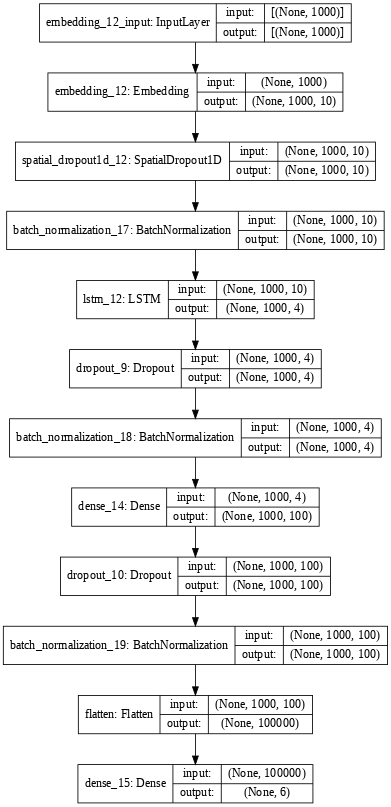

Epoch 1/100
89/89 [==============================] - 9s 83ms/step - loss: 2.6458 - accuracy: 0.4967 - val_loss: 4.7423 - val_accuracy: 0.0739
Epoch 2/100
89/89 [==============================] - 7s 78ms/step - loss: 0.8401 - accuracy: 0.8383 - val_loss: 10.3246 - val_accuracy: 0.0739
Epoch 3/100
89/89 [==============================] - 7s 78ms/step - loss: 0.3868 - accuracy: 0.9316 - val_loss: 7.6493 - val_accuracy: 0.1862
Epoch 4/100
89/89 [==============================] - 7s 78ms/step - loss: 0.3232 - accuracy: 0.9520 - val_loss: 30.7150 - val_accuracy: 0.0739
Epoch 5/100
89/89 [==============================] - 7s 78ms/step - loss: 0.2431 - accuracy: 0.9648 - val_loss: 12.5560 - val_accuracy: 0.3617
Epoch 6/100
89/89 [==============================] - 7s 78ms/step - loss: 0.2835 - accuracy: 0.9647 - val_loss: 14.3965 - val_accuracy: 0.4185
Epoch 7/100
89/89 [==============================] - 7s 78ms/step - loss: 0.2103 - accuracy: 0.9703 - val_loss: 10.9787 - val_accuracy: 0.4159
E

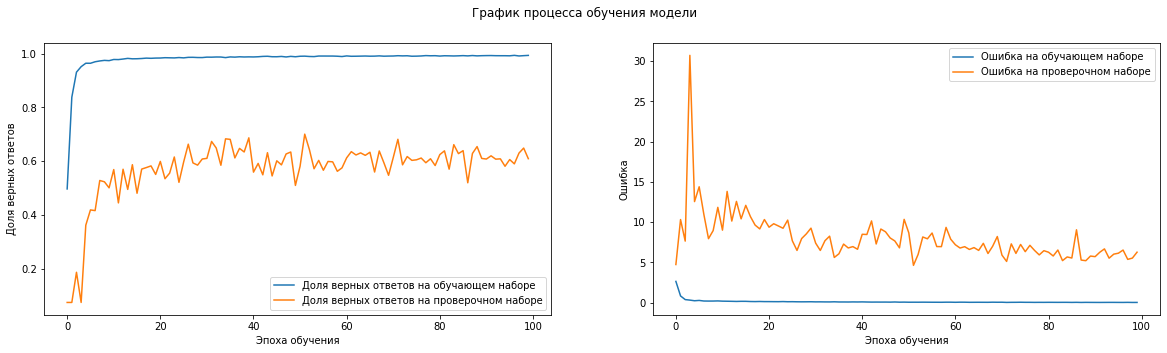

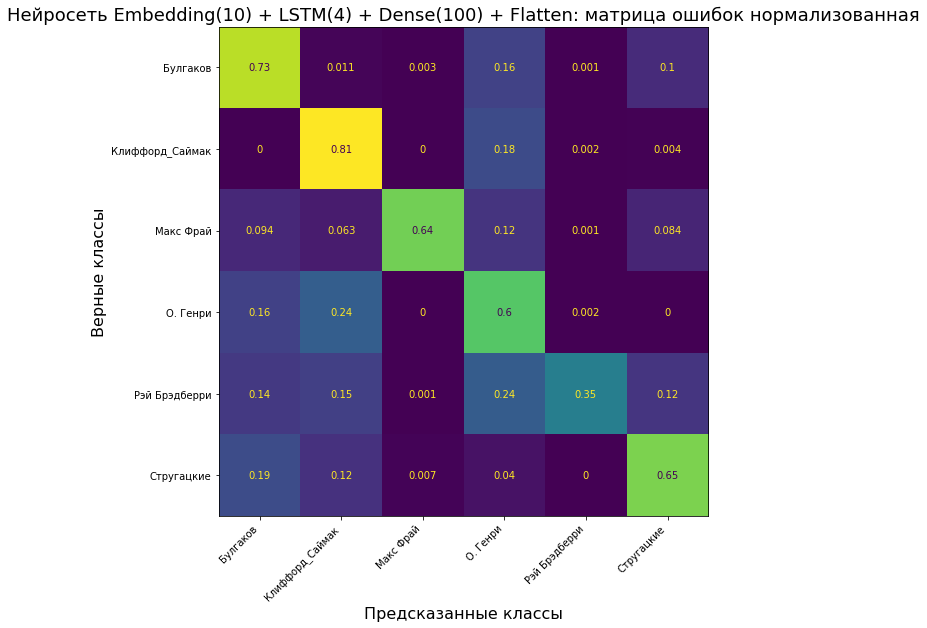

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(10) + LSTM(4) + Dense(100) + Flatten
Класс: Булгаков              73% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       81% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             64% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              60% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         35% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            65% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  63%


In [ ]:
model_LSTM_9 = Sequential()
model_LSTM_9.add(Embedding(VOCAB_SIZE, 10, input_length=WIN_SIZE))
model_LSTM_9.add(SpatialDropout1D(0.4))
model_LSTM_9.add(BatchNormalization())
# Рекуррентный слой LSTM
model_LSTM_9.add(LSTM(4, return_sequences=True))
model_LSTM_9.add(Dropout(0.5))
model_LSTM_9.add(BatchNormalization())
# Дополнительный полносвязный слой
model_LSTM_9.add(Dense(100, activation='relu'))
model_LSTM_9.add(Dropout(0.5))
model_LSTM_9.add(BatchNormalization())
# Слой выравнивания/сглаживания ("сплющивание" данных в вектор)
model_LSTM_9.add(Flatten())
model_LSTM_9.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_LSTM_9,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=200,
                         class_labels=CLASS_LIST,
                         title='Embedding(10) + LSTM(4) + Dense(100) + Flatten')

#### Conv1D

#####**Исследование №17: Conv1D №1**

Model: "sequential_13"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_13 (Embedding)     (None, 1000, 10)          200000    
_________________________________________________________________
spatial_dropout1d_13 (Spatia (None, 1000, 10)          0         
_________________________________________________________________
batch_normalization_20 (Batc (None, 1000, 10)          40        
_________________________________________________________________
conv1d (Conv1D)              (None, 1000, 20)          1020      
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 996, 20)           2020      
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 498, 20)           0         
_________________________________________________________________
dropout_11 (Dropout)         (None, 498, 20)         

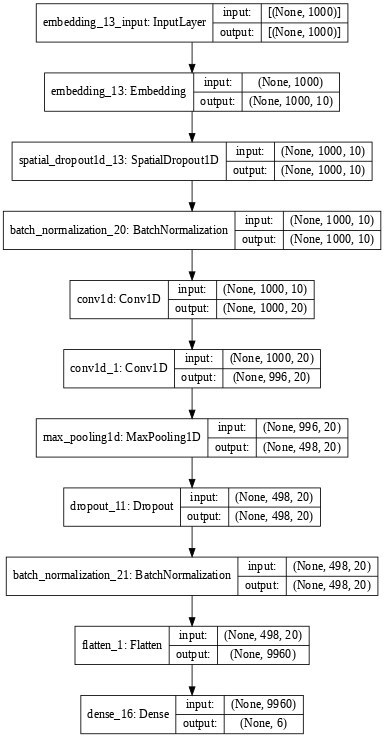

Epoch 1/100
89/89 [==============================] - 29s 27ms/step - loss: 1.1510 - accuracy: 0.5951 - val_loss: 2.1391 - val_accuracy: 0.3045
Epoch 2/100
89/89 [==============================] - 2s 24ms/step - loss: 0.0533 - accuracy: 0.9832 - val_loss: 2.3276 - val_accuracy: 0.2929
Epoch 3/100
89/89 [==============================] - 2s 24ms/step - loss: 0.0190 - accuracy: 0.9935 - val_loss: 3.1719 - val_accuracy: 0.4930
Epoch 4/100
89/89 [==============================] - 2s 24ms/step - loss: 0.0135 - accuracy: 0.9955 - val_loss: 2.7296 - val_accuracy: 0.3981
Epoch 5/100
89/89 [==============================] - 2s 24ms/step - loss: 0.0123 - accuracy: 0.9961 - val_loss: 4.0098 - val_accuracy: 0.3826
Epoch 6/100
89/89 [==============================] - 2s 24ms/step - loss: 0.0123 - accuracy: 0.9960 - val_loss: 2.2800 - val_accuracy: 0.4958
Epoch 7/100
89/89 [==============================] - 2s 24ms/step - loss: 0.0135 - accuracy: 0.9964 - val_loss: 1.9623 - val_accuracy: 0.6051
Epoch

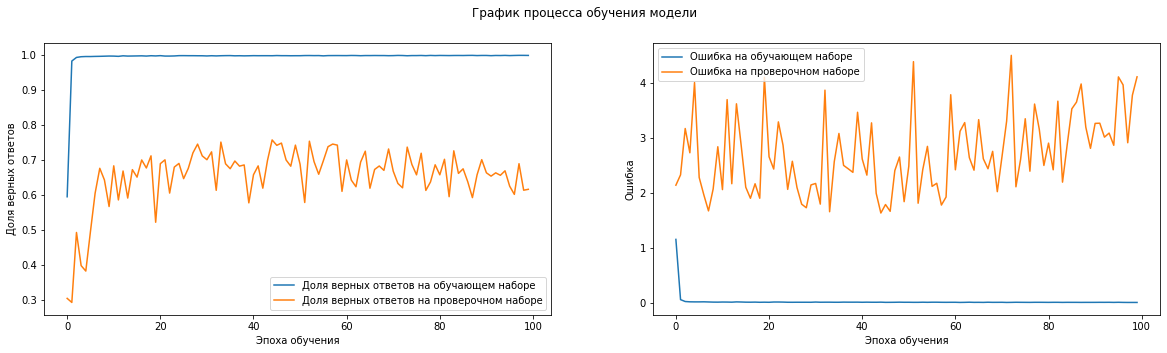

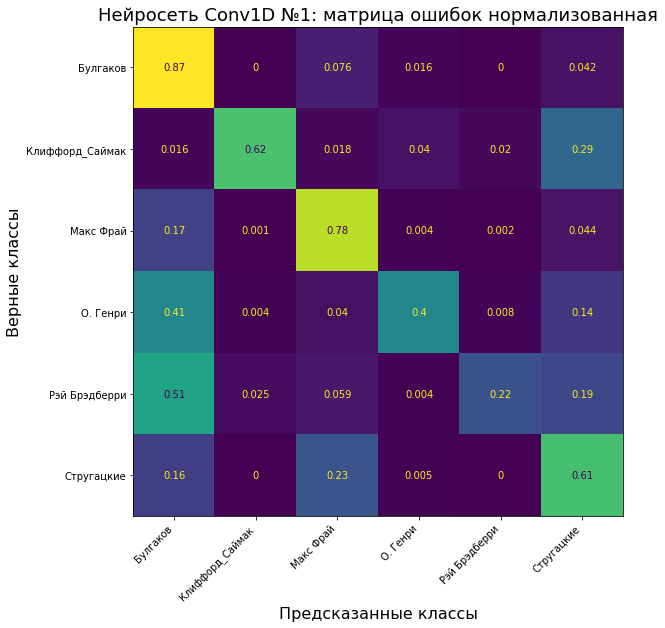

----------------------------------------------------------------------------------------------------
Нейросеть: Conv1D №1
Класс: Булгаков              87% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       62% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             78% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              40% сеть отнесла к классу Булгаков             - НЕВЕРНО :-(
Класс: Рэй Брэдберри         50% сеть отнесла к классу Булгаков             - НЕВЕРНО :-(
Класс: Стругацкие            61% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  58%


In [ ]:
model_Conv_1 = Sequential()
model_Conv_1.add(Embedding(VOCAB_SIZE, 10, input_length=WIN_SIZE))
model_Conv_1.add(SpatialDropout1D(0.2))
model_Conv_1.add(BatchNormalization())
# Два слоя одномерной свертки Conv1D
model_Conv_1.add(Conv1D(20, 5, activation='relu', padding='same'))
model_Conv_1.add(Conv1D(20, 5, activation='relu'))
# Слой подвыборки/пулинга с функцией максимума
model_Conv_1.add(MaxPooling1D(2))
model_Conv_1.add(Dropout(0.2))
model_Conv_1.add(BatchNormalization())
model_Conv_1.add(Flatten())
model_Conv_1.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_Conv_1,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=200,
                         class_labels=CLASS_LIST,
                         title='Conv1D №1')

#####**Исследование №18: Conv1D №2**

Model: "sequential_14"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_14 (Embedding)     (None, 1000, 50)          1000000   
_________________________________________________________________
spatial_dropout1d_14 (Spatia (None, 1000, 50)          0         
_________________________________________________________________
batch_normalization_22 (Batc (None, 1000, 50)          200       
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 1000, 20)          5020      
_________________________________________________________________
conv1d_3 (Conv1D)            (None, 1000, 20)          2020      
_________________________________________________________________
max_pooling1d_1 (MaxPooling1 (None, 500, 20)           0         
_________________________________________________________________
dropout_12 (Dropout)         (None, 500, 20)         

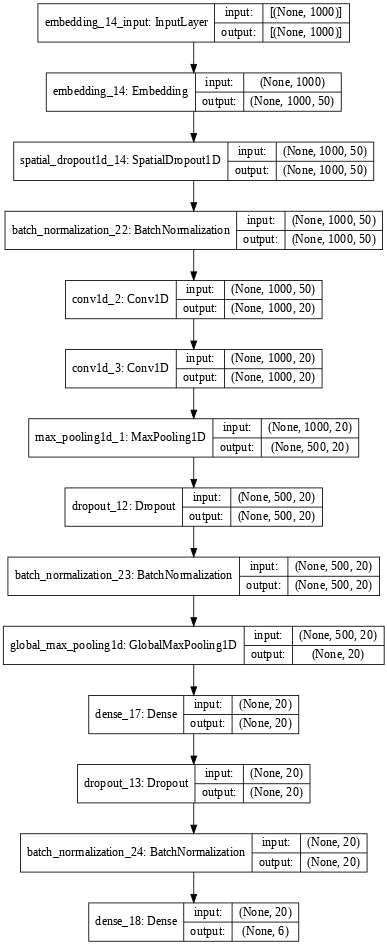

Epoch 1/100
89/89 [==============================] - 7s 62ms/step - loss: 1.2716 - accuracy: 0.5366 - val_loss: 1.7757 - val_accuracy: 0.2929
Epoch 2/100
89/89 [==============================] - 5s 60ms/step - loss: 0.5387 - accuracy: 0.8857 - val_loss: 1.9003 - val_accuracy: 0.2957
Epoch 3/100
89/89 [==============================] - 5s 59ms/step - loss: 0.2754 - accuracy: 0.9576 - val_loss: 1.9441 - val_accuracy: 0.2619
Epoch 4/100
89/89 [==============================] - 5s 60ms/step - loss: 0.1515 - accuracy: 0.9759 - val_loss: 1.8535 - val_accuracy: 0.2348
Epoch 5/100
89/89 [==============================] - 5s 59ms/step - loss: 0.0939 - accuracy: 0.9842 - val_loss: 1.7460 - val_accuracy: 0.2728
Epoch 6/100
89/89 [==============================] - 5s 59ms/step - loss: 0.0570 - accuracy: 0.9906 - val_loss: 1.7134 - val_accuracy: 0.3385
Epoch 7/100
89/89 [==============================] - 5s 59ms/step - loss: 0.0459 - accuracy: 0.9910 - val_loss: 1.7037 - val_accuracy: 0.3827
Epoch 

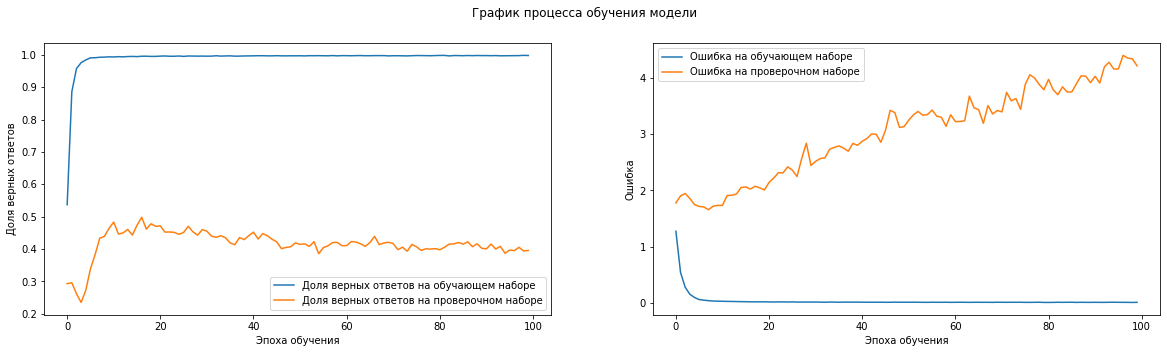

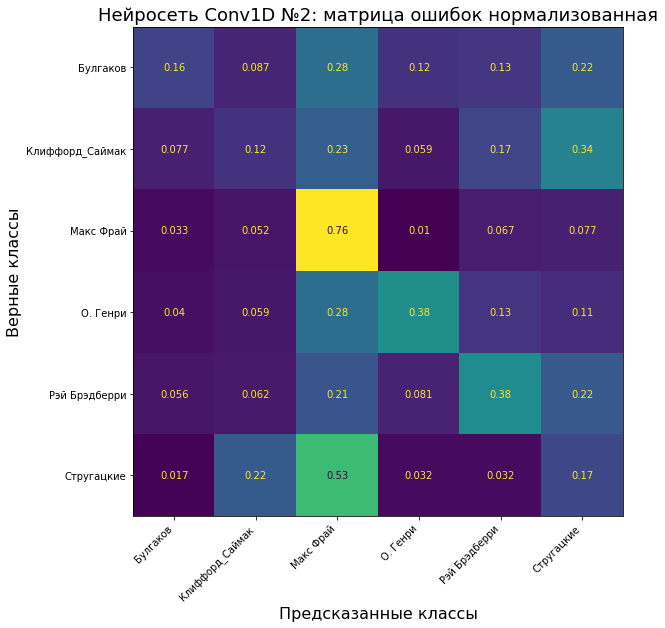

----------------------------------------------------------------------------------------------------
Нейросеть: Conv1D №2
Класс: Булгаков              28% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       34% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Макс Фрай             76% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              38% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         38% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            53% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(

Средняя точность распознавания:  33%


In [ ]:
model_Conv_2 = Sequential()
model_Conv_2.add(Embedding(VOCAB_SIZE, 50, input_length=WIN_SIZE))
model_Conv_2.add(SpatialDropout1D(0.2))
model_Conv_2.add(BatchNormalization())
# Два слоя одномерной свертки Conv1D
model_Conv_2.add(Conv1D(20, 5, activation='relu', padding='same'))
model_Conv_2.add(Conv1D(20, 5, activation='relu', padding='same'))
# Слой подвыборки/пулинга с функцией максимума
model_Conv_2.add(MaxPooling1D(2))
model_Conv_2.add(Dropout(0.2))
model_Conv_2.add(BatchNormalization())
# Слой глобального пулинга с функцией максимума
model_Conv_2.add(GlobalMaxPooling1D())
model_Conv_2.add(Dense(20, activation='relu'))
model_Conv_2.add(Dropout(0.2))
model_Conv_2.add(BatchNormalization())
model_Conv_2.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_Conv_2,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=200,
                         class_labels=CLASS_LIST,
                         title='Conv1D №2')

#####**Исследование №19: Conv1D №3**

Model: "sequential_15"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_15 (Embedding)     (None, 1000, 10)          200000    
_________________________________________________________________
spatial_dropout1d_15 (Spatia (None, 1000, 10)          0         
_________________________________________________________________
batch_normalization_25 (Batc (None, 1000, 10)          40        
_________________________________________________________________
conv1d_4 (Conv1D)            (None, 996, 20)           1020      
_________________________________________________________________
conv1d_5 (Conv1D)            (None, 992, 20)           2020      
_________________________________________________________________
max_pooling1d_2 (MaxPooling1 (None, 496, 20)           0         
_________________________________________________________________
dropout_14 (Dropout)         (None, 496, 20)         

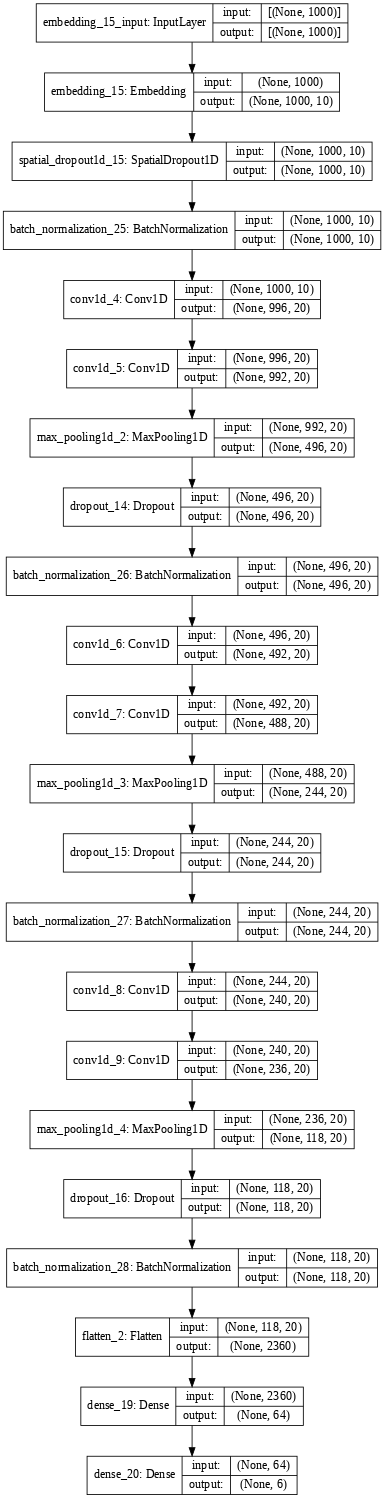

Epoch 1/100
89/89 [==============================] - 7s 41ms/step - loss: 1.3949 - accuracy: 0.4537 - val_loss: 2.7210 - val_accuracy: 0.0739
Epoch 2/100
89/89 [==============================] - 3s 33ms/step - loss: 0.5774 - accuracy: 0.7523 - val_loss: 3.7123 - val_accuracy: 0.1724
Epoch 3/100
89/89 [==============================] - 3s 33ms/step - loss: 0.2318 - accuracy: 0.9135 - val_loss: 3.2418 - val_accuracy: 0.1019
Epoch 4/100
89/89 [==============================] - 3s 33ms/step - loss: 0.0750 - accuracy: 0.9753 - val_loss: 4.6463 - val_accuracy: 0.2955
Epoch 5/100
89/89 [==============================] - 3s 33ms/step - loss: 0.0410 - accuracy: 0.9859 - val_loss: 6.5453 - val_accuracy: 0.2952
Epoch 6/100
89/89 [==============================] - 3s 33ms/step - loss: 0.0338 - accuracy: 0.9896 - val_loss: 2.6916 - val_accuracy: 0.3925
Epoch 7/100
89/89 [==============================] - 3s 32ms/step - loss: 0.0226 - accuracy: 0.9929 - val_loss: 4.4435 - val_accuracy: 0.3685
Epoch 

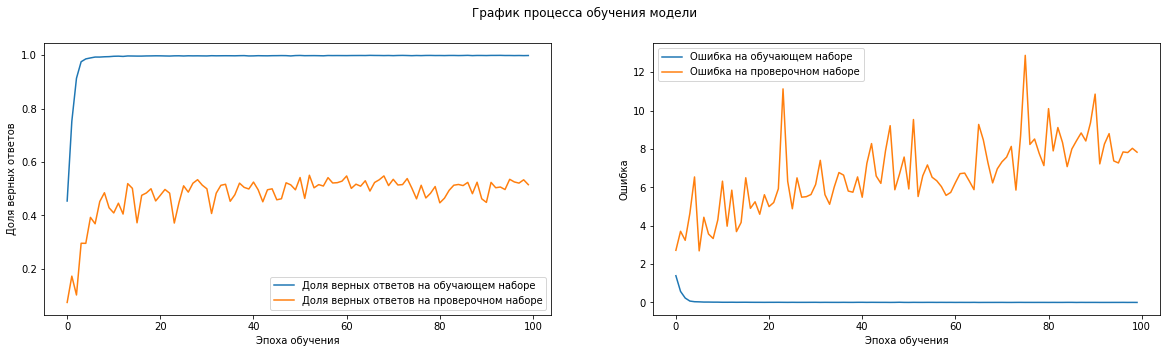

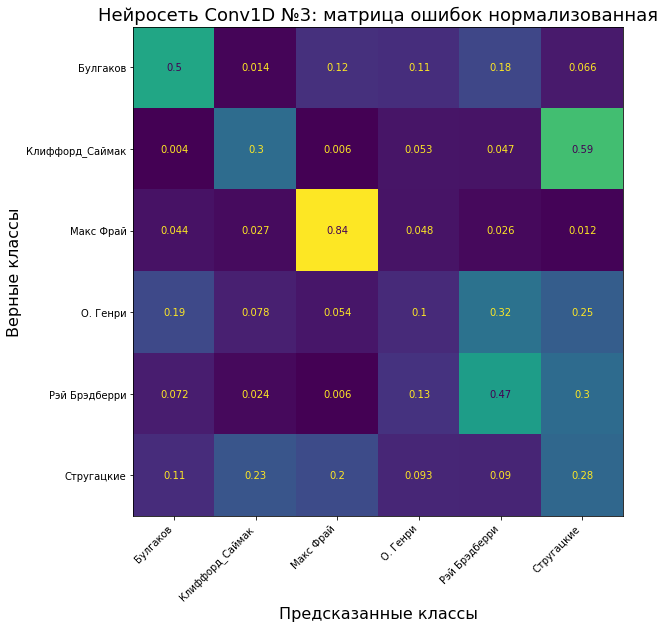

----------------------------------------------------------------------------------------------------
Нейросеть: Conv1D №3
Класс: Булгаков              50% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       59% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Макс Фрай             84% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              32% сеть отнесла к классу Рэй Брэдберри        - НЕВЕРНО :-(
Класс: Рэй Брэдберри         47% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            28% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  42%


In [ ]:
model_Conv_3 = Sequential()
model_Conv_3.add(Embedding(VOCAB_SIZE, 10, input_length=WIN_SIZE))
model_Conv_3.add(SpatialDropout1D(0.2))
model_Conv_3.add(BatchNormalization())
# Два слоя одномерной свертки Conv1D
model_Conv_3.add(Conv1D(20, 5, activation='relu'))
model_Conv_3.add(Conv1D(20, 5, activation='relu'))
# Слой подвыборки/пулинга с функцией максимума
model_Conv_3.add(MaxPooling1D(2))
model_Conv_3.add(Dropout(0.2))
model_Conv_3.add(BatchNormalization())
# Два слоя одномерной свертки Conv1D
model_Conv_3.add(Conv1D(20, 5, activation='relu'))
model_Conv_3.add(Conv1D(20, 5, activation='relu'))
# Слой подвыборки/пулинга с функцией максимума
model_Conv_3.add(MaxPooling1D(2))
model_Conv_3.add(Dropout(0.2))
model_Conv_3.add(BatchNormalization())
# Два слоя одномерной свертки Conv1D
model_Conv_3.add(Conv1D(20, 5, activation='relu'))
model_Conv_3.add(Conv1D(20, 5, activation='relu'))
# Слой подвыборки/пулинга с функцией максимума
model_Conv_3.add(MaxPooling1D(2))
model_Conv_3.add(Dropout(0.2))
model_Conv_3.add(BatchNormalization())
# Слой выравнивания/сглаживания ("сплющивание" данных в вектор)
model_Conv_3.add(Flatten())
model_Conv_3.add(Dense(64, activation='relu'))
model_Conv_3.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_Conv_3,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=200,
                         class_labels=CLASS_LIST,
                         title='Conv1D №3')

#####**Исследование №20: Conv1D №4**

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 1000, 50)          1000000   
_________________________________________________________________
spatial_dropout1d (SpatialDr (None, 1000, 50)          0         
_________________________________________________________________
batch_normalization (BatchNo (None, 1000, 50)          200       
_________________________________________________________________
conv1d (Conv1D)              (None, 996, 20)           5020      
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 498, 20)           0         
_________________________________________________________________
dropout (Dropout)            (None, 498, 20)           0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 498, 20)           8

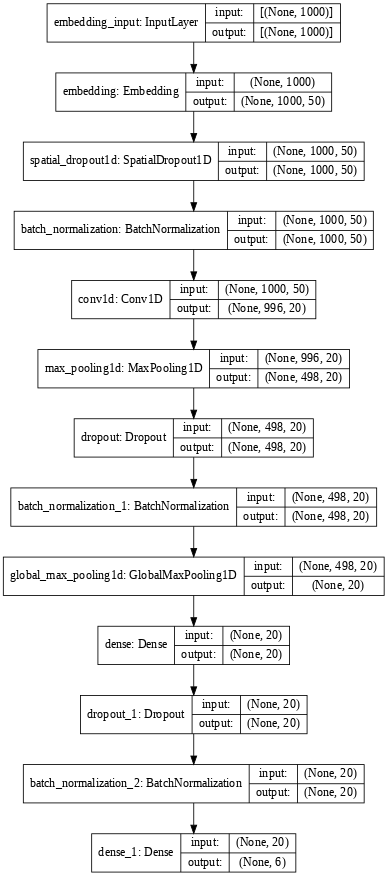

Epoch 1/100
89/89 [==============================] - 37s 59ms/step - loss: 1.1172 - accuracy: 0.6366 - val_loss: 1.7787 - val_accuracy: 0.2632
Epoch 2/100
89/89 [==============================] - 5s 56ms/step - loss: 0.4337 - accuracy: 0.9134 - val_loss: 1.6761 - val_accuracy: 0.3343
Epoch 3/100
89/89 [==============================] - 5s 56ms/step - loss: 0.2292 - accuracy: 0.9562 - val_loss: 1.6655 - val_accuracy: 0.3184
Epoch 4/100
89/89 [==============================] - 5s 56ms/step - loss: 0.1373 - accuracy: 0.9743 - val_loss: 1.7900 - val_accuracy: 0.2963
Epoch 5/100
89/89 [==============================] - 5s 55ms/step - loss: 0.0918 - accuracy: 0.9817 - val_loss: 1.6942 - val_accuracy: 0.3163
Epoch 6/100
89/89 [==============================] - 5s 55ms/step - loss: 0.0696 - accuracy: 0.9843 - val_loss: 1.6565 - val_accuracy: 0.3796
Epoch 7/100
89/89 [==============================] - 5s 55ms/step - loss: 0.0556 - accuracy: 0.9871 - val_loss: 1.6076 - val_accuracy: 0.4266
Epoch

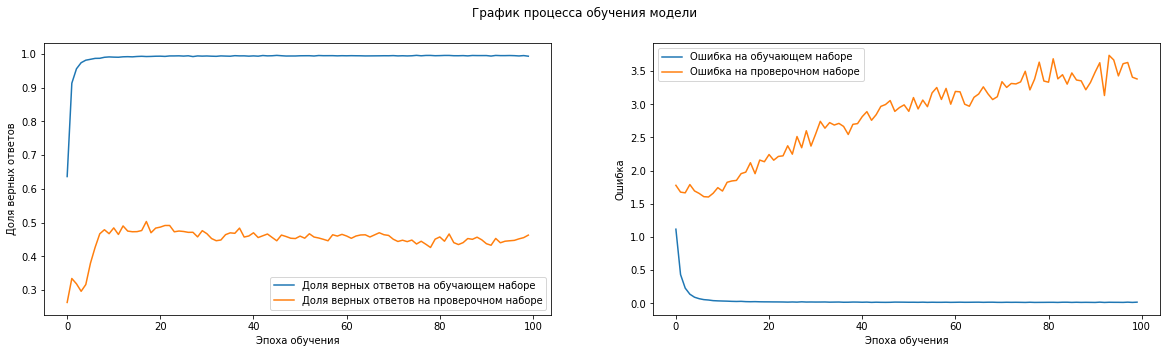

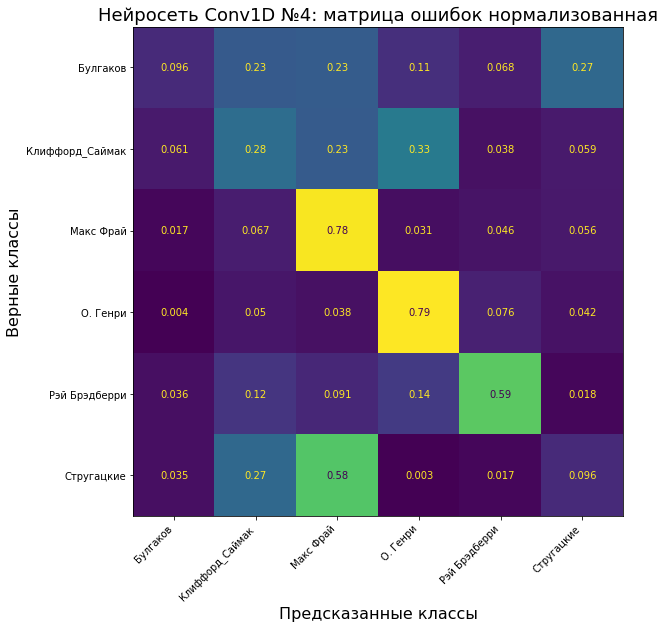

----------------------------------------------------------------------------------------------------
Нейросеть: Conv1D №4
Класс: Булгаков              27% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       33% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(
Класс: Макс Фрай             78% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              79% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         59% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            58% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(

Средняя точность распознавания:  44%


In [ ]:
model_Conv_4 = Sequential()
model_Conv_4.add(Embedding(VOCAB_SIZE, 50, input_length=WIN_SIZE))
model_Conv_4.add(SpatialDropout1D(0.2))
model_Conv_4.add(BatchNormalization())
# Слой одномерной свертки Conv1D
model_Conv_4.add(Conv1D(20, 5, activation='relu'))
# Слой подвыборки/пулинга с функцией максимума
model_Conv_4.add(MaxPooling1D(2))
model_Conv_4.add(Dropout(0.2))
model_Conv_4.add(BatchNormalization())
# Слой глобального пулинга с функцией максимума
model_Conv_4.add(GlobalMaxPooling1D())
# Дополнительный полносвязный слой
model_Conv_4.add(Dense(20, activation='relu'))
model_Conv_4.add(Dropout(0.2))
model_Conv_4.add(BatchNormalization())
model_Conv_4.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_Conv_4,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=200,
                         class_labels=CLASS_LIST,
                         title='Conv1D №4')

#### LSTM + Conv1D

#####**Исследование №21: LSTM + Conv1D №1**

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 1000, 10)          200000    
_________________________________________________________________
spatial_dropout1d_1 (Spatial (None, 1000, 10)          0         
_________________________________________________________________
lstm (LSTM)                  (None, 1000, 4)           240       
_________________________________________________________________
dense_2 (Dense)              (None, 1000, 100)         500       
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 996, 20)           10020     
_________________________________________________________________
lstm_1 (LSTM)                (None, 996, 4)            400       
_________________________________________________________________
dropout_2 (Dropout)          (None, 996, 4)           

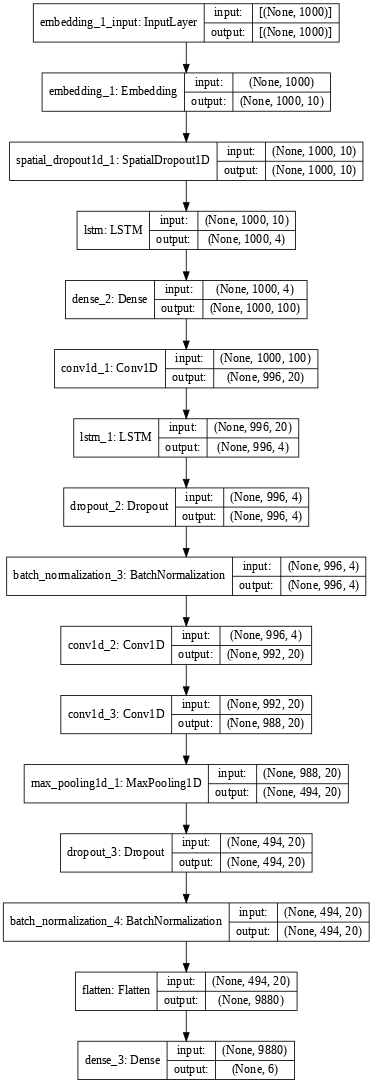

Epoch 1/100
89/89 [==============================] - 15s 109ms/step - loss: 0.7926 - accuracy: 0.6740 - val_loss: 2.6323 - val_accuracy: 0.1968
Epoch 2/100
89/89 [==============================] - 9s 99ms/step - loss: 0.1204 - accuracy: 0.9601 - val_loss: 3.2983 - val_accuracy: 0.1968
Epoch 3/100
89/89 [==============================] - 9s 100ms/step - loss: 0.0432 - accuracy: 0.9865 - val_loss: 4.9832 - val_accuracy: 0.1792
Epoch 4/100
89/89 [==============================] - 9s 99ms/step - loss: 0.0301 - accuracy: 0.9908 - val_loss: 6.4360 - val_accuracy: 0.1336
Epoch 5/100
89/89 [==============================] - 9s 99ms/step - loss: 0.0278 - accuracy: 0.9910 - val_loss: 5.1104 - val_accuracy: 0.2644
Epoch 6/100
89/89 [==============================] - 9s 99ms/step - loss: 0.0213 - accuracy: 0.9931 - val_loss: 4.7237 - val_accuracy: 0.3424
Epoch 7/100
89/89 [==============================] - 9s 99ms/step - loss: 0.0161 - accuracy: 0.9946 - val_loss: 6.8988 - val_accuracy: 0.2291
Epo

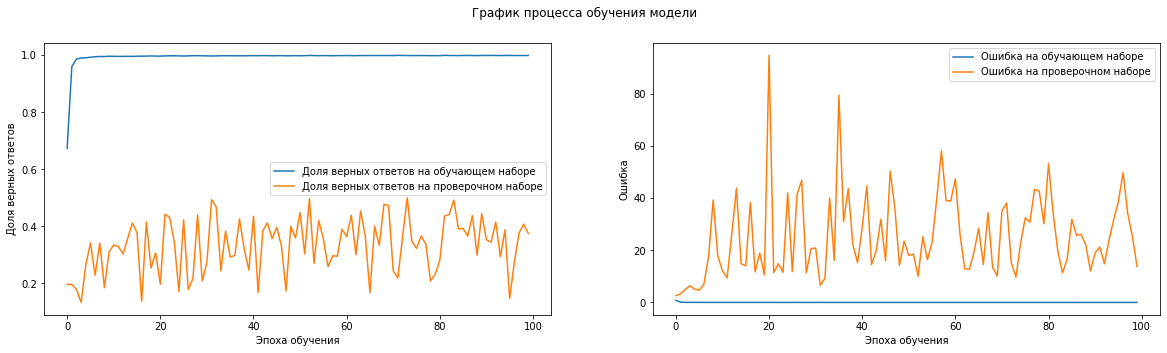

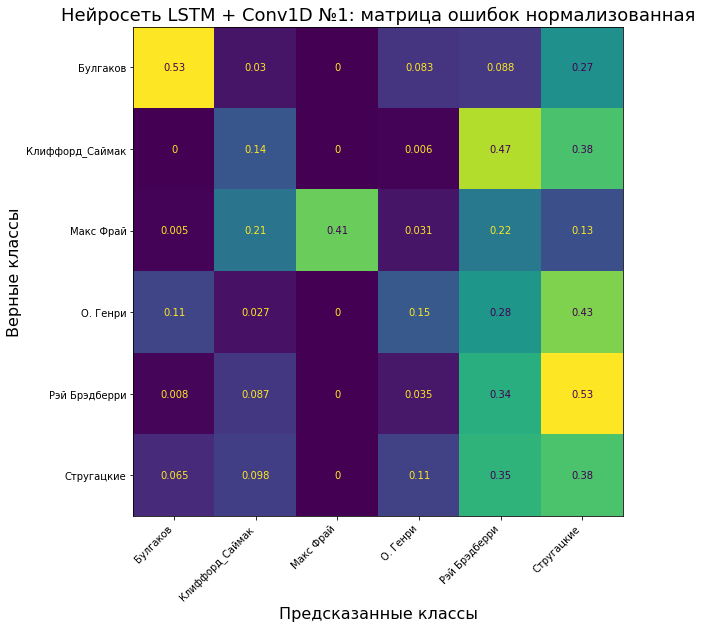

----------------------------------------------------------------------------------------------------
Нейросеть: LSTM + Conv1D №1
Класс: Булгаков              53% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       47% сеть отнесла к классу Рэй Брэдберри        - НЕВЕРНО :-(
Класс: Макс Фрай             41% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              43% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Рэй Брэдберри         53% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Стругацкие            38% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  33%


In [ ]:
model_LC_1 = Sequential()
model_LC_1.add(Embedding(VOCAB_SIZE, 10, input_length=WIN_SIZE))
model_LC_1.add(SpatialDropout1D(0.2))
# Рекуррентный слой LSTM
model_LC_1.add(LSTM(4, return_sequences=1))
# Полносвязный слой
model_LC_1.add(Dense(100, activation='relu'))
# Сверточный слой
model_LC_1.add(Conv1D(20, 5, activation='relu'))
# Рекуррентный слой LSTM
model_LC_1.add(LSTM(4, return_sequences=1))
# Слой регуляризации Dropout
model_LC_1.add(Dropout(0.2))
# Слой пакетной нормализации
model_LC_1.add(BatchNormalization())
# Два сверточных слоя
model_LC_1.add(Conv1D(20, 5, activation='relu'))
model_LC_1.add(Conv1D(20, 5, activation='relu'))
# Слой подвыборки/пулинга с функцией максимума
model_LC_1.add(MaxPooling1D(2))
model_LC_1.add(Dropout(0.2))
model_LC_1.add(BatchNormalization())
# Слой выравнивания/сглаживания ("сплющивание" данных в вектор)
model_LC_1.add(Flatten())
model_LC_1.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_LC_1,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=200,
                         class_labels=CLASS_LIST,
                         title='LSTM + Conv1D №1')

#####**Исследование №22: LSTM + Conv1D №2**

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_2 (Embedding)      (None, 1000, 10)          200000    
_________________________________________________________________
spatial_dropout1d_2 (Spatial (None, 1000, 10)          0         
_________________________________________________________________
lstm_2 (LSTM)                (None, 1000, 4)           240       
_________________________________________________________________
dense_4 (Dense)              (None, 1000, 100)         500       
_________________________________________________________________
conv1d_4 (Conv1D)            (None, 996, 20)           10020     
_________________________________________________________________
lstm_3 (LSTM)                (None, 996, 4)            400       
_________________________________________________________________
max_pooling1d_2 (MaxPooling1 (None, 498, 4)           

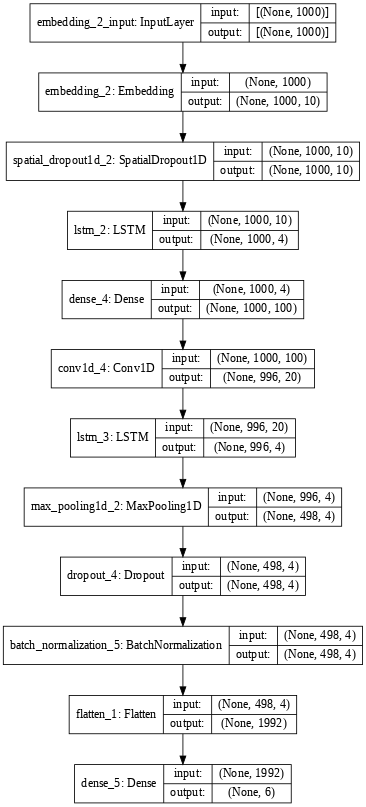

Epoch 1/100
89/89 [==============================] - 12s 99ms/step - loss: 0.7213 - accuracy: 0.6987 - val_loss: 3.3295 - val_accuracy: 0.2929
Epoch 2/100
89/89 [==============================] - 8s 91ms/step - loss: 0.0432 - accuracy: 0.9876 - val_loss: 1.6720 - val_accuracy: 0.3851
Epoch 3/100
89/89 [==============================] - 8s 91ms/step - loss: 0.0130 - accuracy: 0.9956 - val_loss: 1.5209 - val_accuracy: 0.4112
Epoch 4/100
89/89 [==============================] - 8s 92ms/step - loss: 0.0108 - accuracy: 0.9967 - val_loss: 2.6962 - val_accuracy: 0.3943
Epoch 5/100
89/89 [==============================] - 8s 91ms/step - loss: 0.0075 - accuracy: 0.9973 - val_loss: 6.2736 - val_accuracy: 0.3204
Epoch 6/100
89/89 [==============================] - 8s 91ms/step - loss: 0.0070 - accuracy: 0.9976 - val_loss: 6.3529 - val_accuracy: 0.3603
Epoch 7/100
89/89 [==============================] - 8s 91ms/step - loss: 0.0049 - accuracy: 0.9982 - val_loss: 3.2574 - val_accuracy: 0.4939
Epoch

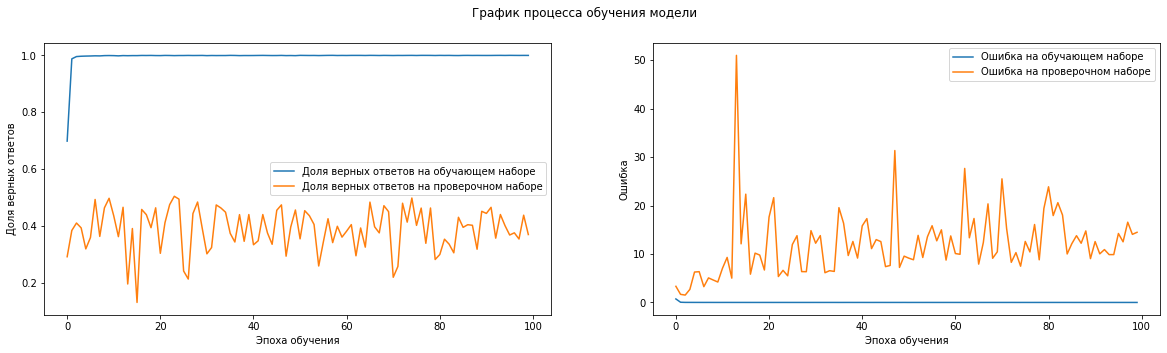

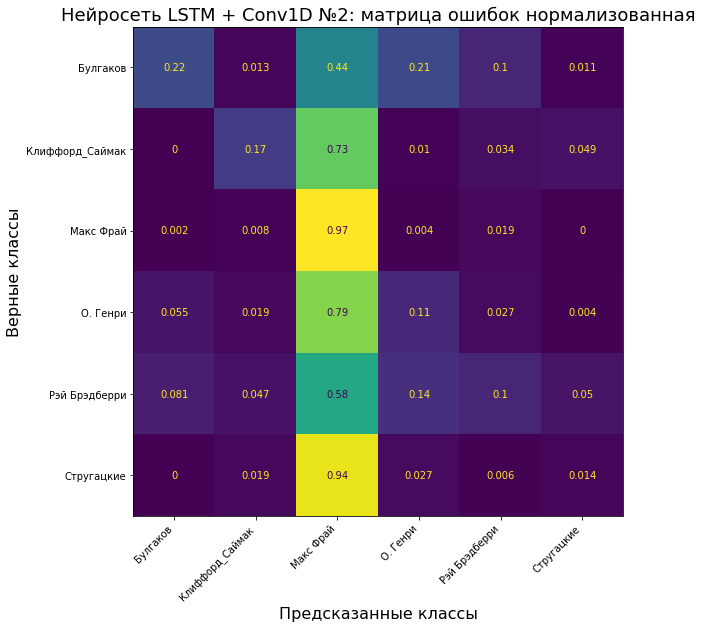

----------------------------------------------------------------------------------------------------
Нейросеть: LSTM + Conv1D №2
Класс: Булгаков              44% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       74% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(
Класс: Макс Фрай             97% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              79% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(
Класс: Рэй Брэдберри         58% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(
Класс: Стругацкие            94% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(

Средняя точность распознавания:  26%


In [ ]:
model_LC_2 = Sequential()
model_LC_2.add(Embedding(VOCAB_SIZE, 10, input_length=WIN_SIZE))
model_LC_2.add(SpatialDropout1D(0.2))
# Рекуррентный слой LSTM
model_LC_2.add(LSTM(4, return_sequences=1))
# Полносвязный слой
model_LC_2.add(Dense(100, activation='relu'))
# Сверточный слой
model_LC_2.add(Conv1D(20, 5, activation='relu'))
# Рекуррентный слой LSTM
model_LC_2.add(LSTM(4, return_sequences=1))
# Слой подвыборки/пулинга с функцией максимума
model_LC_2.add(MaxPooling1D(2))
model_LC_2.add(Dropout(0.2))
model_LC_2.add(BatchNormalization())
# Слой выравнивания/сглаживания ("сплющивание" данных в вектор)
model_LC_2.add(Flatten())
model_LC_2.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_LC_2,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=200,
                         class_labels=CLASS_LIST,
                         title='LSTM + Conv1D №2')

#####**Исследование №23: LSTM + Conv1D №3**

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_3 (Embedding)      (None, 1000, 10)          200000    
_________________________________________________________________
spatial_dropout1d_3 (Spatial (None, 1000, 10)          0         
_________________________________________________________________
conv1d_5 (Conv1D)            (None, 996, 20)           1020      
_________________________________________________________________
max_pooling1d_3 (MaxPooling1 (None, 498, 20)           0         
_________________________________________________________________
dropout_5 (Dropout)          (None, 498, 20)           0         
_________________________________________________________________
batch_normalization_6 (Batch (None, 498, 20)           80        
_________________________________________________________________
lstm_4 (LSTM)                (None, 498, 4)           

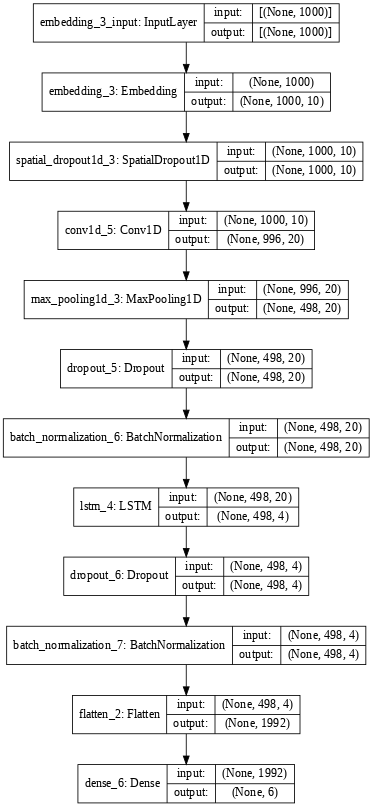

Epoch 1/100
89/89 [==============================] - 5s 40ms/step - loss: 1.0918 - accuracy: 0.6007 - val_loss: 2.4637 - val_accuracy: 0.0739
Epoch 2/100
89/89 [==============================] - 3s 35ms/step - loss: 0.1194 - accuracy: 0.9579 - val_loss: 3.3307 - val_accuracy: 0.2821
Epoch 3/100
89/89 [==============================] - 3s 35ms/step - loss: 0.0286 - accuracy: 0.9916 - val_loss: 2.8459 - val_accuracy: 0.2546
Epoch 4/100
89/89 [==============================] - 3s 35ms/step - loss: 0.0163 - accuracy: 0.9951 - val_loss: 4.0006 - val_accuracy: 0.3035
Epoch 5/100
89/89 [==============================] - 3s 35ms/step - loss: 0.0094 - accuracy: 0.9972 - val_loss: 3.4098 - val_accuracy: 0.4216
Epoch 6/100
89/89 [==============================] - 3s 35ms/step - loss: 0.0095 - accuracy: 0.9968 - val_loss: 4.3274 - val_accuracy: 0.3887
Epoch 7/100
89/89 [==============================] - 3s 36ms/step - loss: 0.0063 - accuracy: 0.9982 - val_loss: 2.9767 - val_accuracy: 0.4717
Epoch 

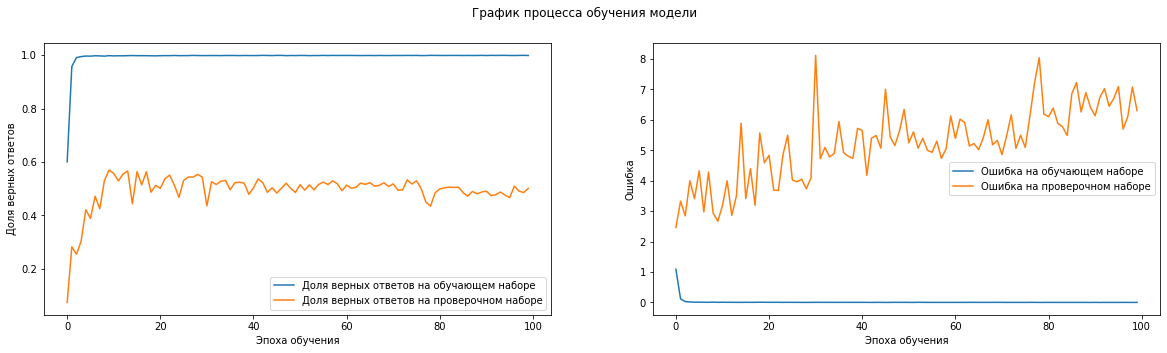

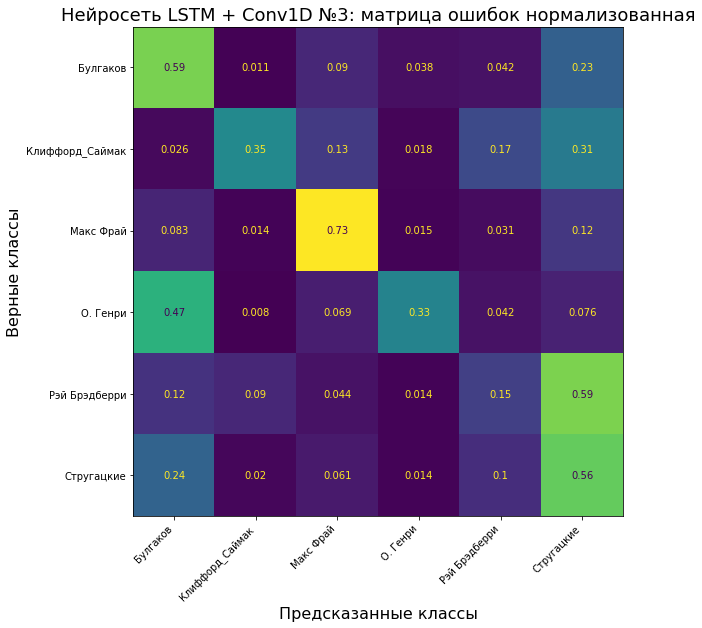

----------------------------------------------------------------------------------------------------
Нейросеть: LSTM + Conv1D №3
Класс: Булгаков              59% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       35% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             73% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              47% сеть отнесла к классу Булгаков             - НЕВЕРНО :-(
Класс: Рэй Брэдберри         59% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Стругацкие            56% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  45%


In [ ]:
model_LC_3 = Sequential()
model_LC_3.add(Embedding(VOCAB_SIZE, 10, input_length=WIN_SIZE))
model_LC_3.add(SpatialDropout1D(0.2))
# Сверточный слой
model_LC_3.add(Conv1D(20, 5, activation='relu'))
# Слой подвыборки/пулинга с функцией максимума
model_LC_3.add(MaxPooling1D(2))
# Слой регуляризации Dropout
model_LC_3.add(Dropout(0.2))
# Слой пакетной нормализации
model_LC_3.add(BatchNormalization())
# Рекуррентный слой LSTM
model_LC_3.add(LSTM(4, return_sequences=1))
model_LC_3.add(Dropout(0.2))
model_LC_3.add(BatchNormalization())
# Слой выравнивания/сглаживания ("сплющивание" данных в вектор)
model_LC_3.add(Flatten())
model_LC_3.add(Dense(CLASS_COUNT, activation='softmax'))

compile_train_eval_model(model_LC_3,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=200,
                         class_labels=CLASS_LIST,
                         title='LSTM + Conv1D №3')

**Содержание темы**

1. [Теория](https://colab.research.google.com/drive/1-T3yr1Qc7KW0KOYwRdYh5x6woNyMXelj?usp=sharing)

2. Практический ноутбук

